# Klasifikasi Tingkat Kesehatan Mental Mahasiswa
## Berdasarkan Faktor Akademik dan Gaya Hidup

---
| Item | Keterangan |
|------|------------|
| **Dataset** | Student Mental Health & Burnout Dataset (1.000.000 data) |
| **Sampling** | Stratified random sample → **20.000 data** |
| **Target** | `risk_level` — Low / Medium / High (Klasifikasi Multi-kelas) |
| **Algoritma** | Random Forest · XGBoost · Gradient Boosting |
| **Tuning** | GridSearchCV (5-Fold Stratified KFold) |
---

## 0. Install & Import Library

In [1]:
!pip install xgboost -q

# ── Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)

# ── Algoritma
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# ── Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# ── Scipy
from scipy import stats

# Gaya plot global
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
COLORS  = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']
C_CLASS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#E91E63'}
RANDOM_STATE = 42

import xgboost
print('Semua library berhasil diimpor!')
print(f'   XGBoost version : {xgboost.__version__}')

Semua library berhasil diimpor!
   XGBoost version : 3.2.0


---
## 1. Data Understanding

### 1.1 Load Dataset & Stratified Sampling 20.000 Data

In [2]:
# ── Upload File ─────────────────────────────────────────────────────
# Opsi A: Upload manual
# from google.colab import files
# uploaded = files.upload()
# FILE_PATH = list(uploaded.keys())[0]

# Opsi B: Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/student_mental_health_burnout_1M.csv'

# Opsi C: File sudah ada di direktori Colab
FILE_PATH = 'student_mental_health_burnout_1M.csv'

# ── Load dataset lengkap ────────────────────────────────────────────
print('Memuat dataset (1 juta baris)... Harap tunggu...')
df_full = pd.read_csv(FILE_PATH)
print(f'Dataset penuh dimuat: {df_full.shape[0]:,} baris × {df_full.shape[1]} kolom')
print(f'\n Distribusi risk_level (full dataset):')
print(df_full['risk_level'].value_counts())

# ── Stratified Sampling → 20.000 data ──────────────────────────────
TARGET_SAMPLE = 2000
np.random.seed(RANDOM_STATE)

groups = []
for lbl, grp in df_full.groupby('risk_level'):
    n = round(TARGET_SAMPLE * len(grp) / len(df_full))
    groups.append(grp.sample(n=n, random_state=RANDOM_STATE))

df = (pd.concat(groups)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True))

print(f'\n Stratified Sampling selesai:')
print(f'   Ukuran sample : {len(df):,} baris')
print(f'   Proporsi      : {len(df)/len(df_full)*100:.1f}% dari dataset asli')
print(f'\n Distribusi risk_level (sample):')
vc = df['risk_level'].value_counts()
for lbl, cnt in vc.items():
    print(f'   {lbl:<8}: {cnt:,}  ({cnt/len(df)*100:.1f}%)')

df.head(8)

Memuat dataset (1 juta baris)... Harap tunggu...
Dataset penuh dimuat: 1,000,000 baris × 20 kolom

 Distribusi risk_level (full dataset):
risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64

 Stratified Sampling selesai:
   Ukuran sample : 2,000 baris
   Proporsi      : 0.2% dari dataset asli

 Distribusi risk_level (sample):
   Low     : 1,533  (76.6%)
   Medium  : 437  (21.9%)
   High    : 30  (1.5%)


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,25,Female,4,7.074380,7.491044,75.152197,6.777380,6.149902,2.261833,6.857982,3.421245,3.826341,5.266052,5.242311,6.572286,6.710366,4.057827,4.765528,Medium,2.424297
1,27,Female,4,5.177991,5.129233,70.464195,4.523072,2.385707,2.327954,7.331320,3.213033,5.549515,4.022131,4.037661,9.536553,4.108238,0.215442,6.776673,Low,0.431620
2,17,Male,3,1.685140,3.234116,79.754496,2.624968,2.399769,0.000000,8.613503,2.648639,6.965254,5.318307,4.370466,7.880066,6.443567,0.000000,8.230082,Low,0.999945
3,20,Female,3,5.971735,5.602248,71.194012,4.224893,3.690947,1.057013,4.641364,4.423792,5.769200,5.214298,3.912647,5.725729,6.117739,2.508703,6.885655,Low,1.071123
4,29,Female,3,5.279143,5.422336,68.425423,4.301268,0.807886,1.826682,7.384267,1.845535,3.545083,7.371666,9.678462,4.685616,3.456727,0.000000,7.489123,Low,0.066433
5,22,Male,1,7.919887,7.378498,78.211945,3.615208,0.326061,0.769039,5.815370,4.642332,6.510362,4.618130,3.090571,2.694331,6.074839,0.000000,8.225387,Low,0.000000
6,17,Male,3,6.418501,5.315178,68.736472,2.929021,2.282961,0.691140,6.276800,0.961899,5.531488,5.069187,7.341944,4.019185,8.449401,0.000000,7.936161,Low,0.000000
7,19,Male,3,6.250891,7.699969,76.118552,5.911092,4.917782,1.623794,3.993414,3.573091,4.344096,8.303023,7.750179,4.310827,3.407701,4.088514,5.673090,Medium,2.282308


### 1.2 Deskripsi Variabel Dataset

In [3]:
deskripsi = {
    'age'                 : 'Usia mahasiswa (17–29 tahun)',
    'gender'              : 'Jenis kelamin (Male / Female / Other)',
    'academic_year'       : 'Tahun akademik (1–4)',
    'study_hours_per_day' : 'Rata-rata jam belajar per hari',
    'exam_pressure'       : 'Tekanan ujian (skor)',
    'academic_performance': 'Performa akademik (skor)',
    'stress_level'        : 'Tingkat stres (skor)',
    'anxiety_score'       : 'Skor kecemasan',
    'depression_score'    : 'Skor depresi',
    'sleep_hours'         : 'Rata-rata jam tidur per malam',
    'physical_activity'   : 'Frekuensi aktivitas fisik (skor)',
    'social_support'      : 'Tingkat dukungan sosial (skor)',
    'screen_time'         : 'Waktu layar per hari (jam)',
    'internet_usage'      : 'Penggunaan internet per hari (jam)',
    'financial_stress'    : 'Tingkat stres finansial (skor)',
    'family_expectation'  : 'Tekanan ekspektasi keluarga (skor)',
    'burnout_score'       : 'Skor burnout (kelelahan akademik)',
    'mental_health_index' : 'Indeks kesehatan mental (skor 0–10)',
    'dropout_risk'        : 'Risiko dropout (skor kontinu)',
    'risk_level'          : 'TARGET: Low / Medium / High'
}
desc_df = pd.DataFrame(list(deskripsi.items()), columns=['Variabel','Deskripsi'])
display(desc_df.style.set_properties(**{'text-align':'left'}).hide(axis='index'))
print()
df.info()

Variabel,Deskripsi
age,Usia mahasiswa (17–29 tahun)
gender,Jenis kelamin (Male / Female / Other)
academic_year,Tahun akademik (1–4)
study_hours_per_day,Rata-rata jam belajar per hari
exam_pressure,Tekanan ujian (skor)
academic_performance,Performa akademik (skor)
stress_level,Tingkat stres (skor)
anxiety_score,Skor kecemasan
depression_score,Skor depresi
sleep_hours,Rata-rata jam tidur per malam



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20001 non-null  int64  
 1   gender                20001 non-null  object 
 2   academic_year         20001 non-null  int64  
 3   study_hours_per_day   20001 non-null  float64
 4   exam_pressure         20001 non-null  float64
 5   academic_performance  20001 non-null  float64
 6   stress_level          20001 non-null  float64
 7   anxiety_score         20001 non-null  float64
 8   depression_score      20001 non-null  float64
 9   sleep_hours           20001 non-null  float64
 10  physical_activity     20001 non-null  float64
 11  social_support        20001 non-null  float64
 12  screen_time           20001 non-null  float64
 13  internet_usage        20001 non-null  float64
 14  financial_stress      20001 non-null  float64
 15  family_expectation

### 1.3 Statistik Deskriptif

In [4]:
display(df.describe().T.style.background_gradient(cmap='Blues').format(precision=3))

,count,mean,std,min,25%,50%,75%,max
age,20001.000,22.979,3.754,17.000,20.000,23.000,26.000,29.000
academic_year,20001.000,2.503,1.116,1.000,2.000,3.000,4.000,4.000
study_hours_per_day,20001.000,5.010,1.993,0.000,3.653,5.016,6.346,12.903
exam_pressure,20001.000,6.008,1.555,1.000,4.942,6.002,7.075,10.000
academic_performance,20001.000,71.049,5.621,48.083,67.261,71.059,74.873,92.596
stress_level,20001.000,4.264,1.676,0.000,3.116,4.268,5.405,10.000
anxiety_score,20001.000,2.989,1.504,0.000,1.933,2.973,4.022,9.571
depression_score,20001.000,1.283,1.218,0.000,0.027,1.063,2.091,6.744
sleep_hours,20001.000,6.491,1.471,3.000,5.475,6.490,7.488,10.000
physical_activity,20001.000,2.997,1.468,0.000,1.959,2.990,4.007,7.000


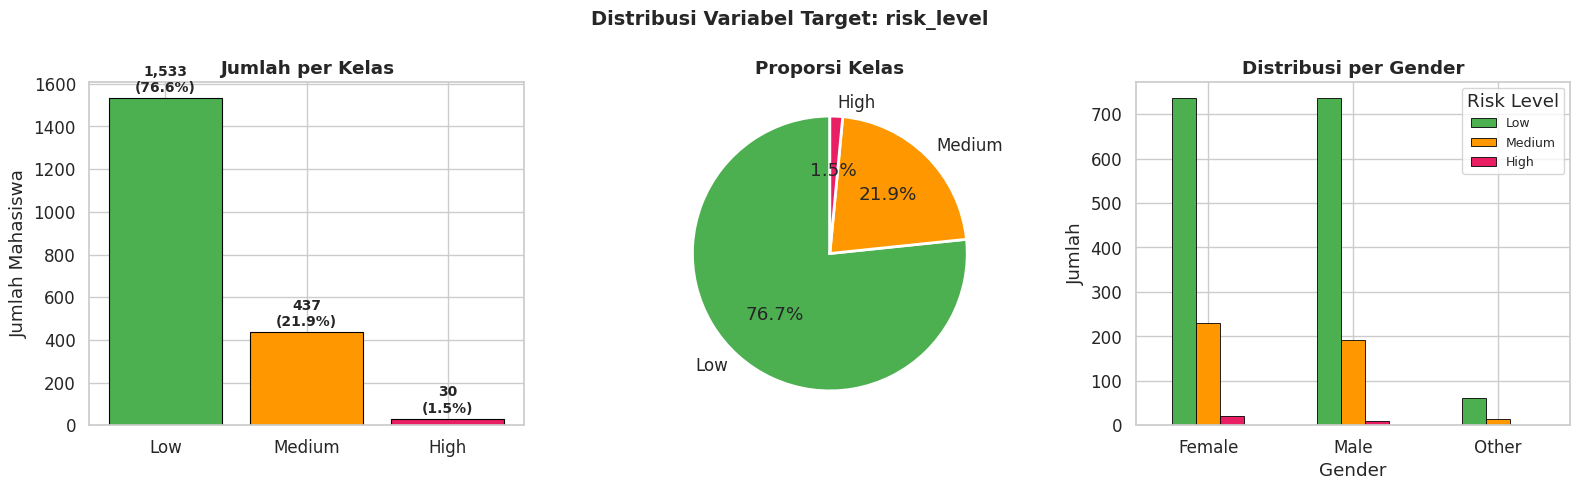

Catatan: Dataset memiliki class imbalance (Low >> Medium >> High)
→ Ditangani dengan class_weight="balanced" pada model.


In [3]:
# Distribusi target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
vc = df['risk_level'].value_counts().reindex(['Low','Medium','High'])
bars = axes[0].bar(vc.index, vc.values,
                   color=[C_CLASS[l] for l in vc.index],
                   edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Mahasiswa')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[C_CLASS[l] for l in vc.index],
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Proporsi Kelas', fontweight='bold')

# Distribusi per gender
ct = pd.crosstab(df['gender'], df['risk_level'])[['Low','Medium','High']]
ct.plot(kind='bar', ax=axes[2], color=[C_CLASS[c] for c in ct.columns],
        edgecolor='black', linewidth=0.6)
axes[2].set_title('Distribusi per Gender', fontweight='bold')
axes[2].set_xlabel('Gender'); axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Risk Level', fontsize=9)

plt.suptitle('Distribusi Variabel Target: risk_level', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Catatan: Dataset memiliki class imbalance (Low >> Medium >> High)')
print('→ Ditangani dengan class_weight="balanced" pada model.')

---
## 🔧 2. Data Preprocessing

### 2.1 Cek Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
mv_df = pd.DataFrame({'Missing Count': missing, 'Persentase (%)': missing_pct.round(2)})
mv_df = mv_df[mv_df['Missing Count'] > 0]

if len(mv_df) == 0:
    print('Tidak ada missing values — Dataset bersih!')
else:
    print(f'Ditemukan {mv_df["Missing Count"].sum()} missing values:')
    display(mv_df.style.background_gradient(cmap='Reds'))
    # Imputasi dengan median (numerik) / modus (kategorik)
    for col in mv_df.index:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
    print('Missing values berhasil diimputasi.')

Tidak ada missing values — Dataset bersih!


### 2.2 Deteksi & Penanganan Outlier (IQR Capping)

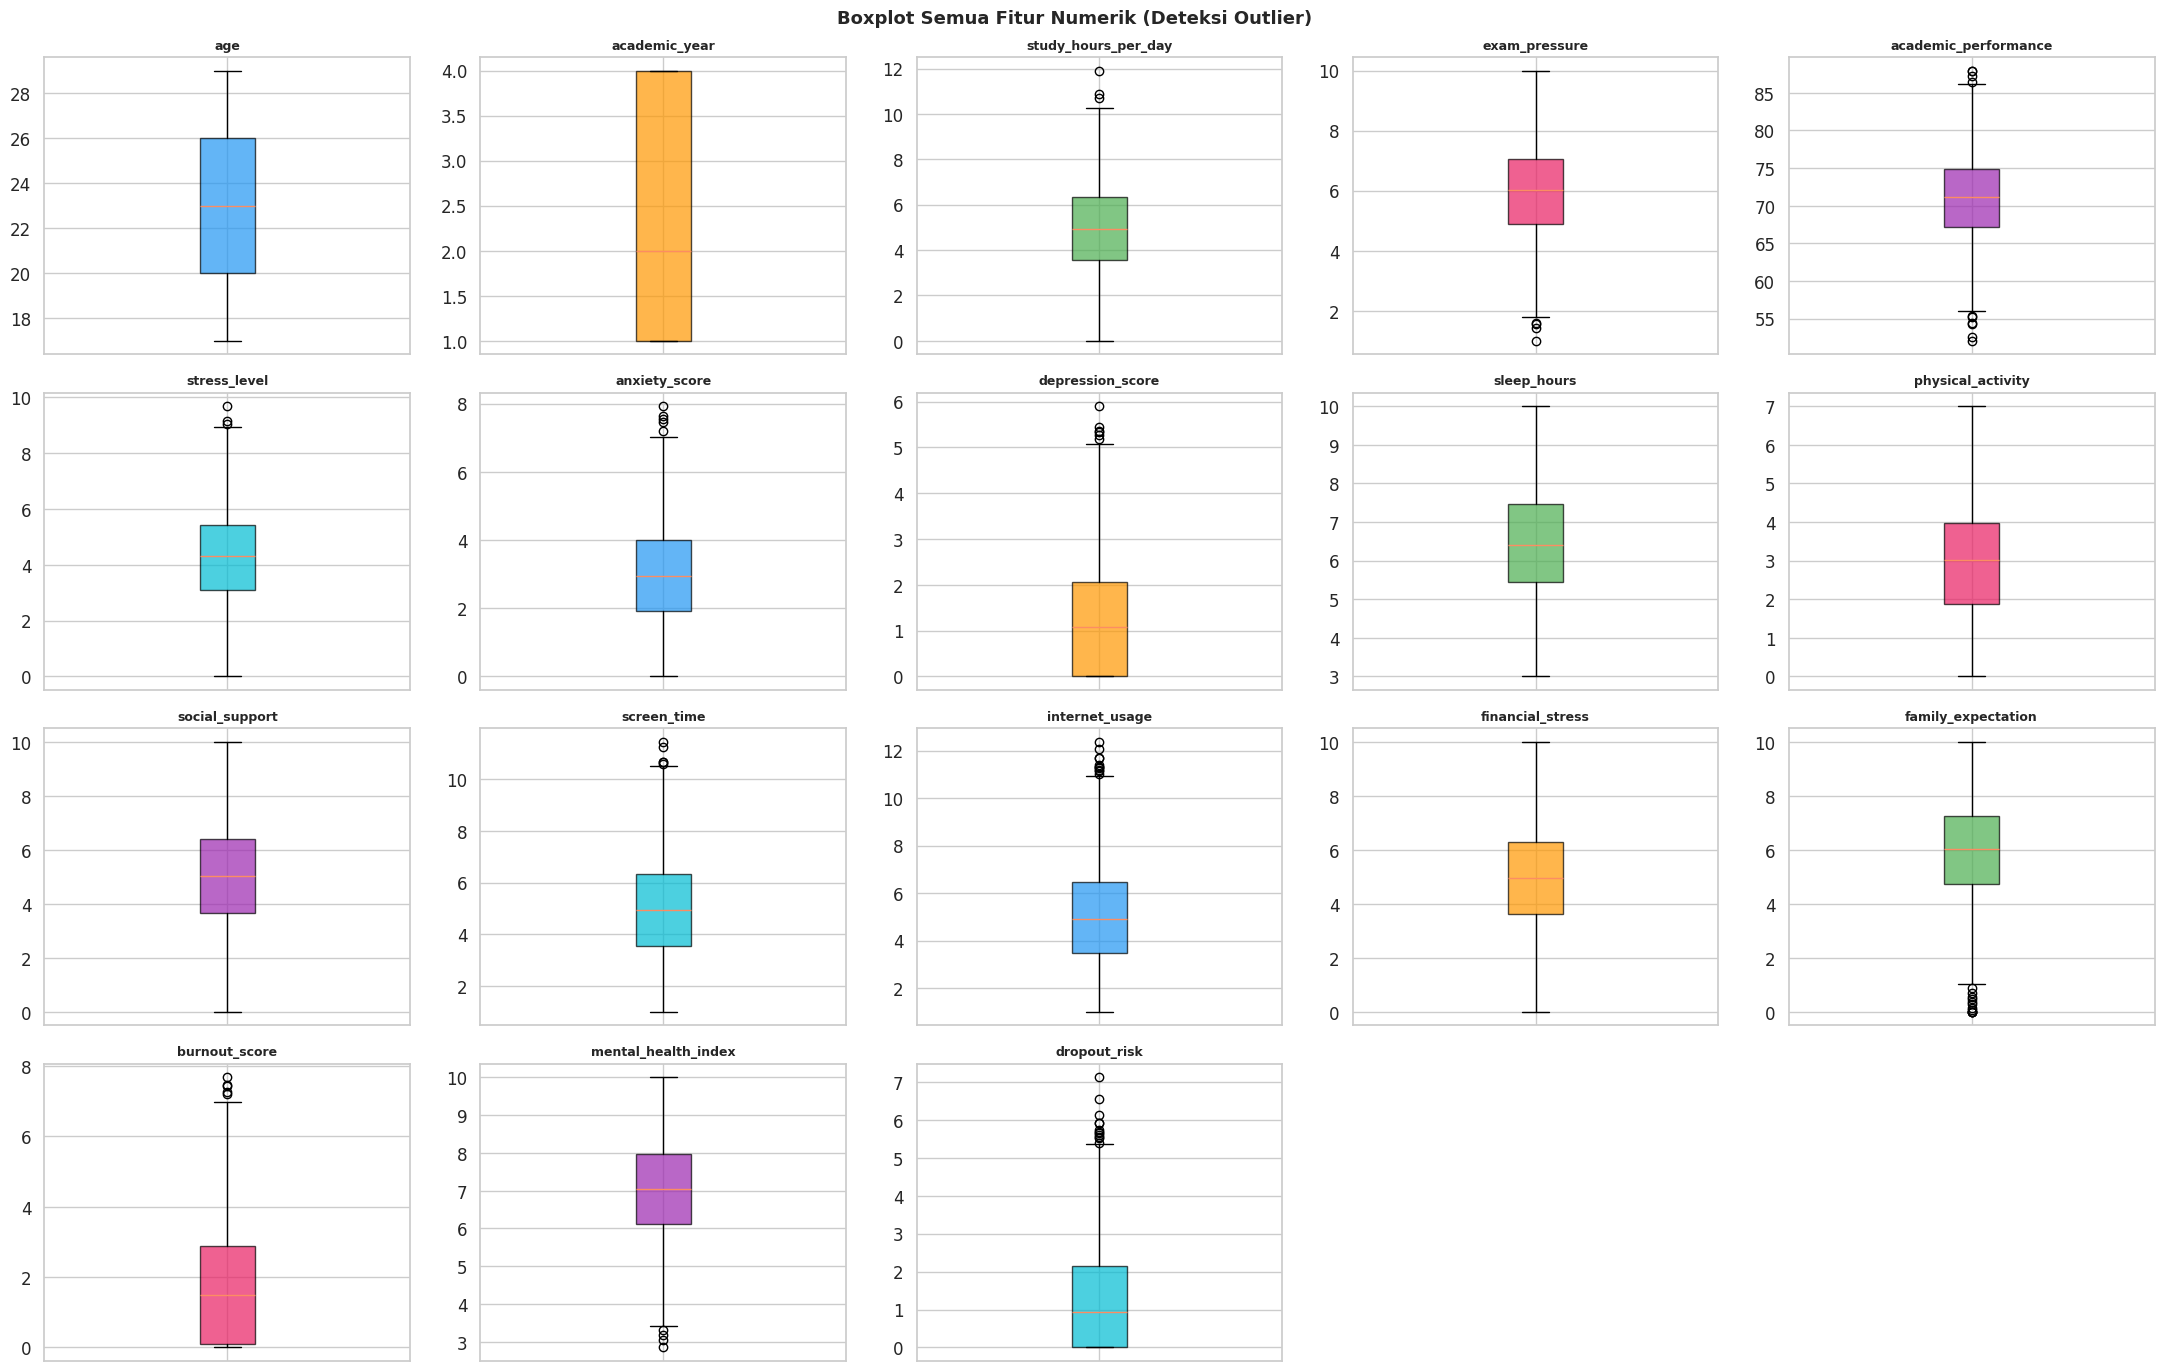

,Fitur,Lower Bound,Upper Bound,Outlier Ditangani
0,age,11.000000,35.000000,0
1,academic_year,-3.500000,8.500000,0
2,study_hours_per_day,-0.579000,10.502000,3
3,exam_pressure,1.682000,10.255000,4
4,academic_performance,55.717000,86.402000,10
5,stress_level,-0.421000,8.943000,3
6,anxiety_score,-1.236000,7.146000,5
7,depression_score,-3.060000,5.117000,6
8,sleep_hours,2.418000,10.497000,0
9,physical_activity,-1.280000,7.136000,0



 IQR Capping selesai. Total outlier ditangani: 80


In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()

# Boxplot sebelum capping
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=COLORS[i%len(COLORS)], alpha=0.7))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticklabels([])
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot Semua Fitur Numerik (Deteksi Outlier)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# IQR Capping
df_clean = df.copy()
report_out = []
for col in num_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    report_out.append({'Fitur':col,'Lower Bound':round(lo,3),'Upper Bound':round(hi,3),'Outlier Ditangani':n_out})

report_out_df = pd.DataFrame(report_out)
display(report_out_df.style.background_gradient(cmap='Oranges', subset=['Outlier Ditangani']))
print(f'\n IQR Capping selesai. Total outlier ditangani: {report_out_df["Outlier Ditangani"].sum():,}')

### 2.3 Encoding Variabel Kategorikal

In [6]:
df_enc = df_clean.copy()

# Gender: Label Encoding (3 kategori)
le_gender = LabelEncoder()
df_enc['gender_enc'] = le_gender.fit_transform(df_enc['gender'])
print('Gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# Target: Label Encoding
le_target = LabelEncoder()
df_enc['target'] = le_target.fit_transform(df_enc['risk_level'])
label_map = dict(zip(le_target.transform(le_target.classes_), le_target.classes_))
print('Target encoding:', label_map)

print(f'\nDistribusi target (encoded):')
print(df_enc['target'].value_counts().sort_index())
print(f'\n Encoding selesai.')

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Target encoding: {np.int64(0): 'High', np.int64(1): 'Low', np.int64(2): 'Medium'}

Distribusi target (encoded):
target
0      30
1    1533
2     437
Name: count, dtype: int64

 Encoding selesai.


### 2.4 Feature Engineering

In [7]:
def feature_engineering(df):
    """
    Menambah fitur baru berdasarkan domain knowledge kesehatan mental mahasiswa.
    Fitur-fitur ini membantu model menangkap pola yang lebih kompleks.
    """
    d = df.copy()

    # ── Fitur Komposit Psikologis ──────────────────────────────────
    d['psy_load']         = d['anxiety_score'] + d['depression_score'] + d['stress_level']
    d['burnout_x_stress'] = d['burnout_score'] * d['stress_level']
    d['mental_vs_burnout']= d['mental_health_index'] - d['burnout_score']

    # ── Fitur Gaya Hidup ──────────────────────────────────────────
    d['lifestyle_score']  = d['sleep_hours'] + d['physical_activity'] - d['screen_time']
    d['screen_sleep_ratio']= d['screen_time'] / (d['sleep_hours'] + 0.1)
    d['study_sleep_ratio'] = d['study_hours_per_day'] / (d['sleep_hours'] + 0.1)

    # ── Fitur Akademik ────────────────────────────────────────────
    d['academic_stress_idx']= d['exam_pressure'] + d['family_expectation'] - d['academic_performance']
    d['perf_vs_pressure']  = d['academic_performance'] - d['exam_pressure']

    # ── Fitur Sosial & Finansial ─────────────────────────────────
    d['support_deficit']   = d['financial_stress'] - d['social_support']
    d['total_external_stress'] = d['financial_stress'] + d['family_expectation'] + d['exam_pressure']

    # ── Fitur Polinomial Kunci ────────────────────────────────────
    d['burnout_sq']        = d['burnout_score'] ** 2
    d['mhi_sq']            = d['mental_health_index'] ** 2
    d['stress_sq']         = d['stress_level'] ** 2

    return d

df_feat = feature_engineering(df_enc)
new_feats = [c for c in df_feat.columns if c not in df_enc.columns]
print(f'Fitur asli    : {len(df_enc.columns) - 2}  (minus target & encoded)')
print(f'Fitur baru    : {len(new_feats)}')
print(f'\nFitur baru:')
for f in new_feats:
    print(f'  + {f}')

Fitur asli    : 20  (minus target & encoded)
Fitur baru    : 13

Fitur baru:
  + psy_load
  + burnout_x_stress
  + mental_vs_burnout
  + lifestyle_score
  + screen_sleep_ratio
  + study_sleep_ratio
  + academic_stress_idx
  + perf_vs_pressure
  + support_deficit
  + total_external_stress
  + burnout_sq
  + mhi_sq
  + stress_sq


### 2.5 Pisahkan Fitur & Target + Standarisasi

In [8]:
# Fitur yang digunakan (semua numerik + engineered)
FEATURE_COLS = [
    'age','academic_year','study_hours_per_day','exam_pressure',
    'academic_performance','stress_level','anxiety_score','depression_score',
    'sleep_hours','physical_activity','social_support','screen_time',
    'internet_usage','financial_stress','family_expectation',
    'burnout_score','mental_health_index','dropout_risk','gender_enc',
    # Engineered
    'psy_load','burnout_x_stress','mental_vs_burnout',
    'lifestyle_score','screen_sleep_ratio','study_sleep_ratio',
    'academic_stress_idx','perf_vs_pressure','support_deficit',
    'total_external_stress','burnout_sq','mhi_sq','stress_sq'
]

X = df_feat[FEATURE_COLS].values
y = df_feat['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape X (scaled): {X_scaled.shape}')
print(f'Shape y          : {y.shape}')
print(f'Kelas target     : {label_map}')
print(f'\n Standarisasi selesai (mean≈0, std≈1)')

Shape X (scaled): (2000, 32)
Shape y          : (2000,)
Kelas target     : {np.int64(0): 'High', np.int64(1): 'Low', np.int64(2): 'Medium'}

 Standarisasi selesai (mean≈0, std≈1)


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Fitur Utama per Kelas

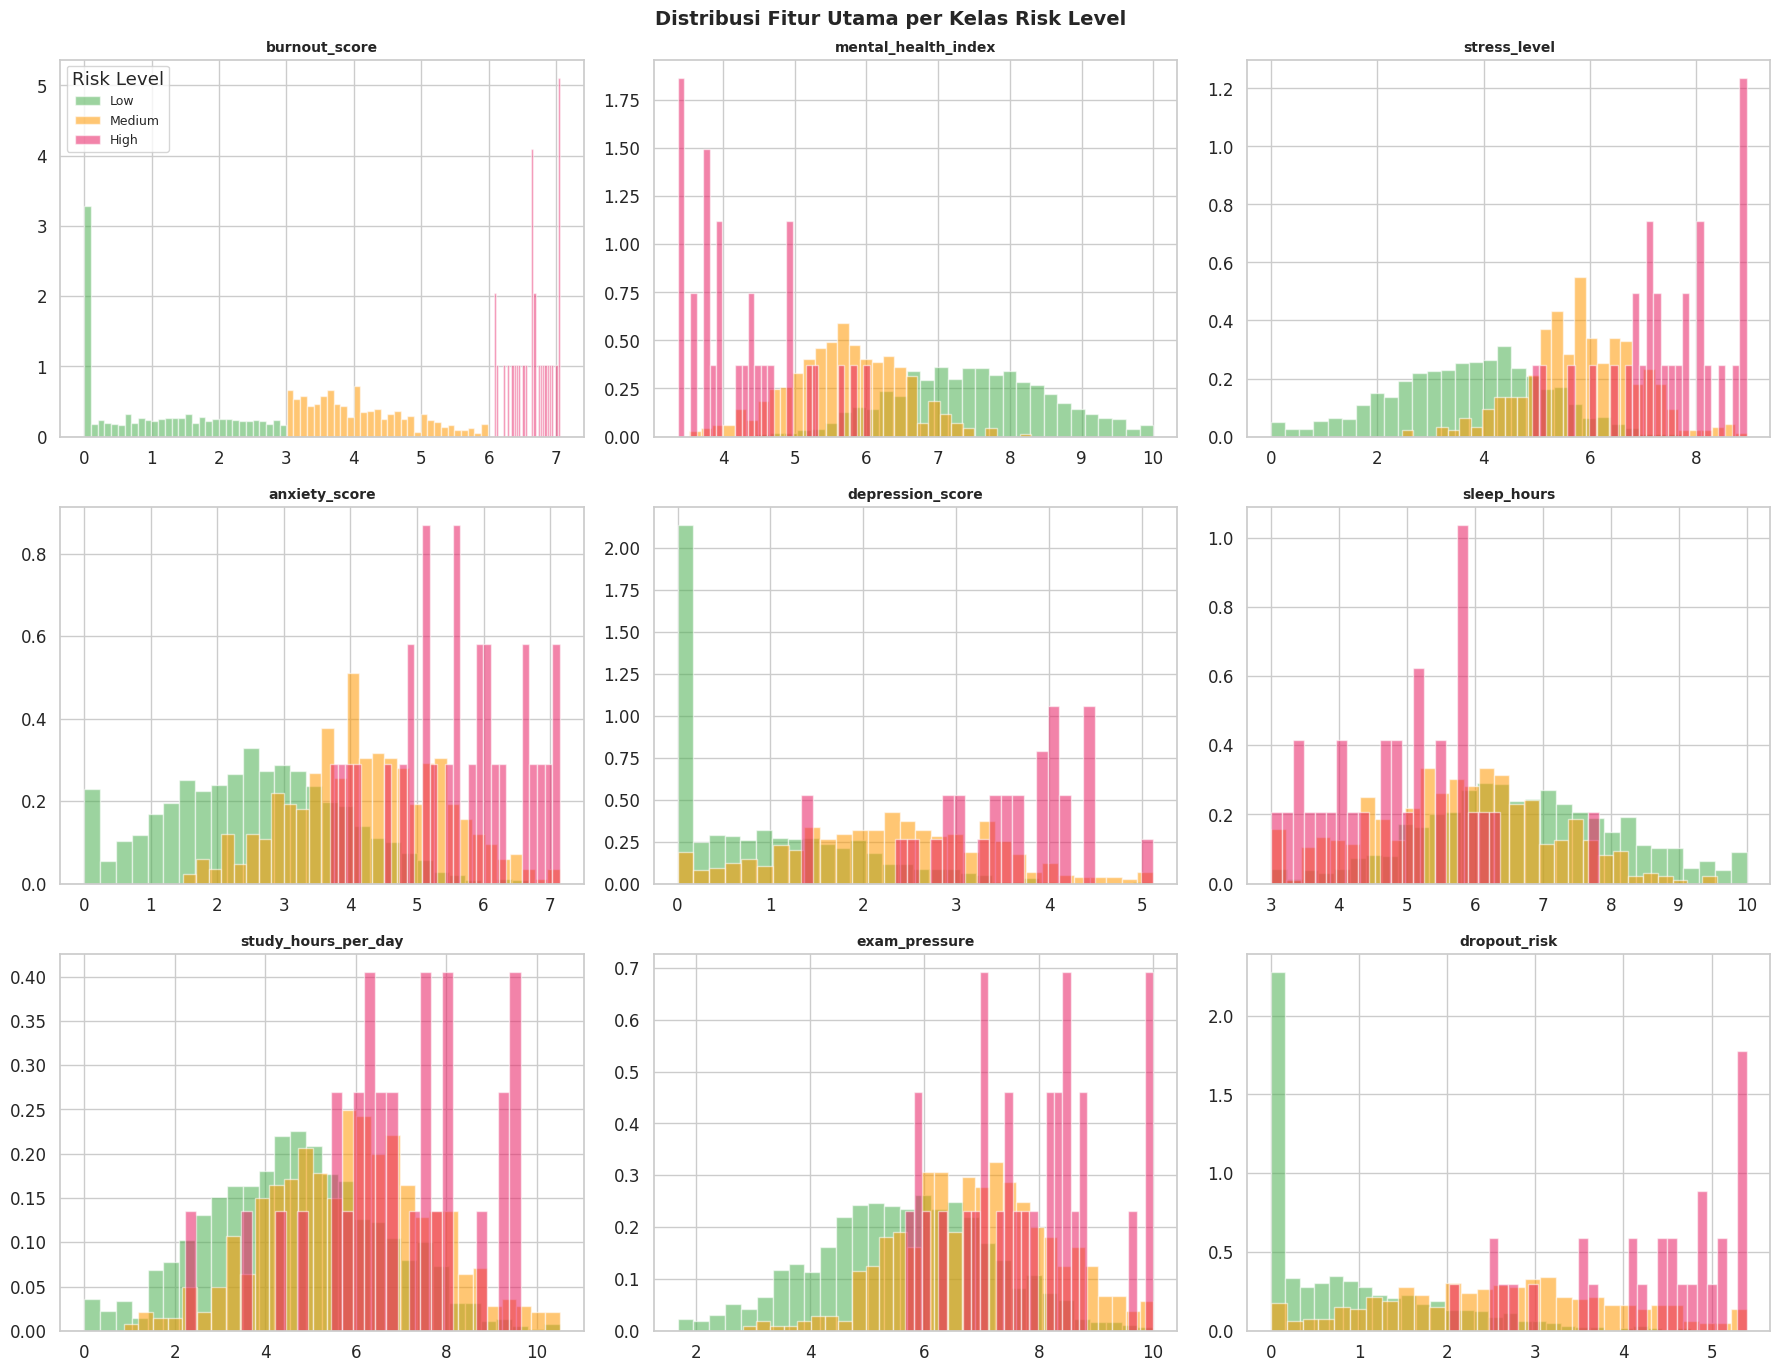

In [9]:
key_feats = ['burnout_score','mental_health_index','stress_level',
             'anxiety_score','depression_score','sleep_hours',
             'study_hours_per_day','exam_pressure','dropout_risk']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_feats):
    for lbl, clr in C_CLASS.items():
        subset = df_clean[df_clean['risk_level']==lbl][col]
        axes[i].hist(subset, bins=30, alpha=0.55, color=clr,
                     label=lbl, density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    if i==0: axes[i].legend(title='Risk Level', fontsize=9)

plt.suptitle('Distribusi Fitur Utama per Kelas Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.2 Heatmap Korelasi

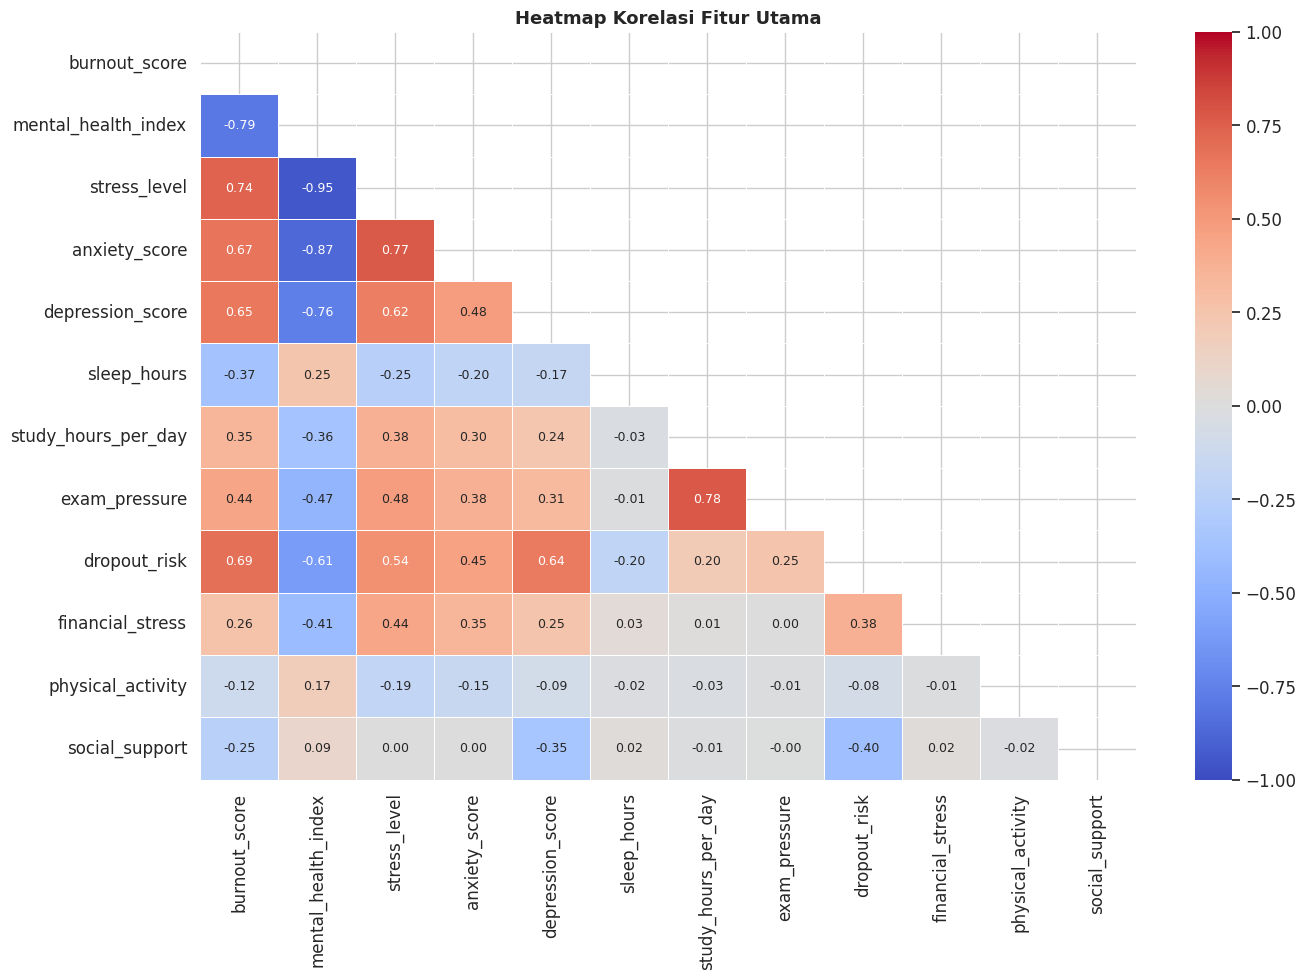

In [10]:
corr_cols = ['burnout_score','mental_health_index','stress_level','anxiety_score',
             'depression_score','sleep_hours','study_hours_per_day','exam_pressure',
             'dropout_risk','financial_stress','physical_activity','social_support']

plt.figure(figsize=(14, 10))
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0, annot_kws={'size':9})
plt.title('Heatmap Korelasi Fitur Utama', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 Korelasi Fitur dengan Target (Spearman)

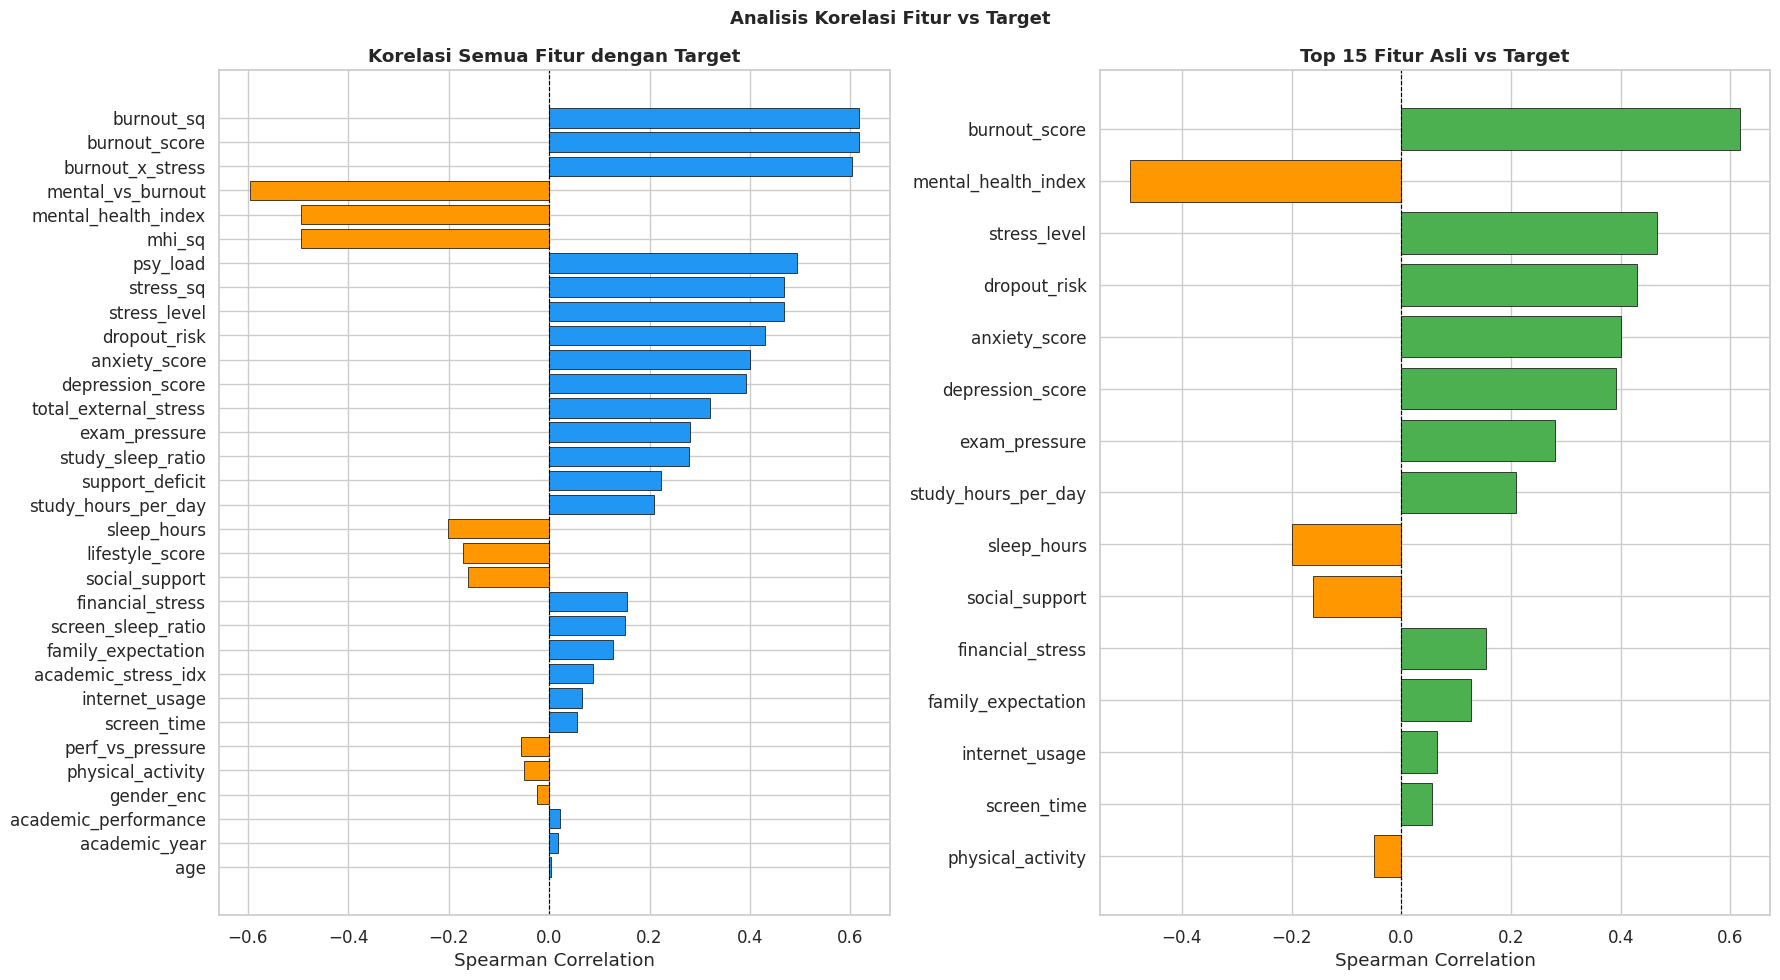

Top 10 fitur paling berkorelasi dengan risk_level:
              Fitur  Spearman r
      burnout_score    0.617466
         burnout_sq    0.617466
   burnout_x_stress    0.603859
  mental_vs_burnout   -0.595915
             mhi_sq   -0.494131
mental_health_index   -0.494131
           psy_load    0.493019
       stress_level    0.466723
          stress_sq    0.466723
       dropout_risk    0.430101


In [11]:
spear_corr = []
for col in FEATURE_COLS:
    r, p = stats.spearmanr(df_feat[col], df_feat['target'])
    spear_corr.append({'Fitur': col, 'Spearman r': r, 'p-value': p})
spear_df = pd.DataFrame(spear_corr).sort_values('Spearman r', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Semua fitur
colors_bar = [COLORS[1] if v < 0 else COLORS[0] for v in spear_df['Spearman r']]
axes[0].barh(spear_df['Fitur'], spear_df['Spearman r'], color=colors_bar,
             edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Spearman Correlation')
axes[0].set_title('Korelasi Semua Fitur dengan Target', fontweight='bold')

# Top 15 fitur original
orig_feats = [c for c in FEATURE_COLS if c not in new_feats]
top_orig = spear_df[spear_df['Fitur'].isin(orig_feats)].tail(15)
col_orig = [COLORS[1] if v<0 else COLORS[2] for v in top_orig['Spearman r']]
axes[1].barh(top_orig['Fitur'], top_orig['Spearman r'], color=col_orig,
             edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Spearman Correlation')
axes[1].set_title('Top 15 Fitur Asli vs Target', fontweight='bold')

plt.suptitle('Analisis Korelasi Fitur vs Target', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top 10 fitur paling berkorelasi dengan risk_level:')
print(spear_df.sort_values('Spearman r', key=abs, ascending=False).head(10)
      [['Fitur','Spearman r']].to_string(index=False))

### 3.4 Violin Plot Fitur Kunci per Kelas

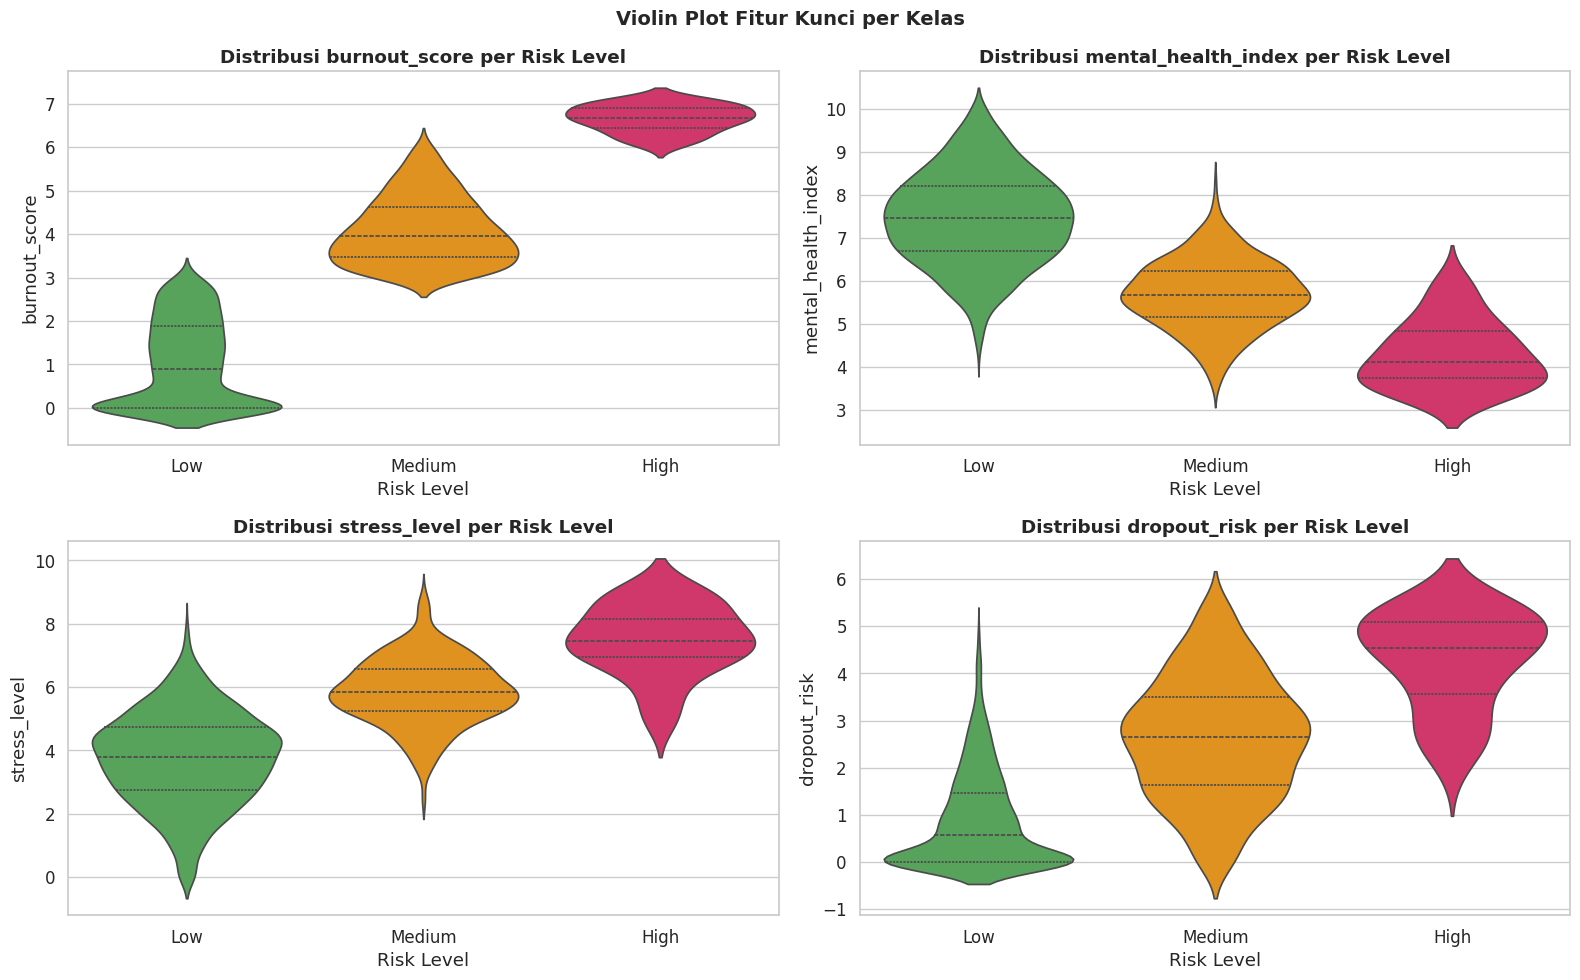

In [12]:
viol_feats = ['burnout_score','mental_health_index','stress_level','dropout_risk']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

order = ['Low','Medium','High']
palette = {'Low':C_CLASS['Low'],'Medium':C_CLASS['Medium'],'High':C_CLASS['High']}

for i, col in enumerate(viol_feats):
    df_v = df_clean[['risk_level', col]]
    sns.violinplot(data=df_v, x='risk_level', y=col, order=order,
                   palette=palette, ax=axes[i], inner='quartile')
    axes[i].set_title(f'Distribusi {col} per Risk Level', fontweight='bold')
    axes[i].set_xlabel('Risk Level')

plt.suptitle('Violin Plot Fitur Kunci per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.5 Pairplot Fitur Terkuat

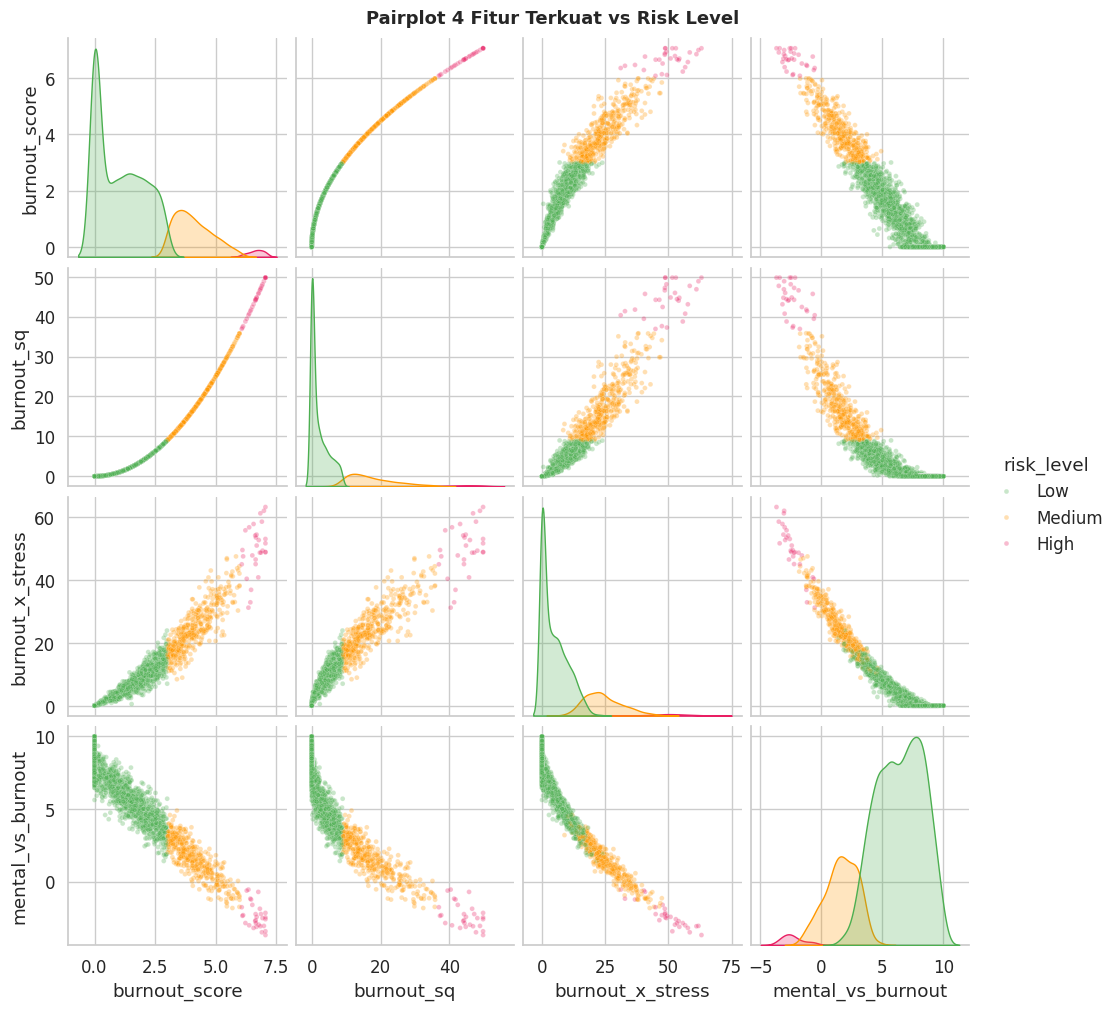

In [13]:
top5_feats = spear_df.sort_values('Spearman r', key=abs, ascending=False)['Fitur'].head(4).tolist()
pair_df = df_feat[top5_feats + ['risk_level']].copy()

g = sns.pairplot(pair_df, hue='risk_level', hue_order=['Low','Medium','High'],
                 palette=palette, plot_kws={'alpha':0.3,'s':12}, diag_kind='kde')
g.figure.suptitle('Pairplot 4 Fitur Terkuat vs Risk Level', y=1.01,
                   fontsize=13, fontweight='bold')
plt.show()

### 3.6 Insight: Rata-rata Fitur per Kelas

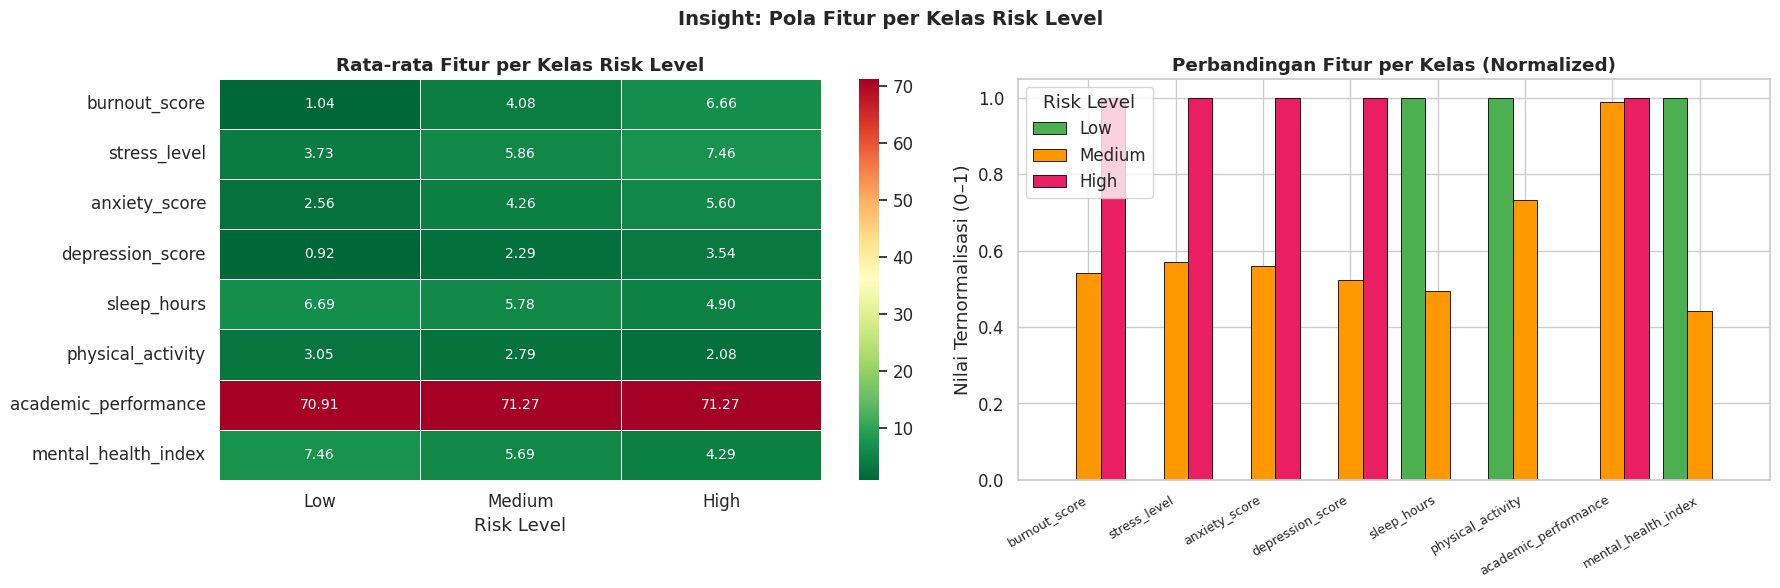


Insight Utama:
  • Kelas HIGH memiliki burnout_score & stress_level tertinggi
  • Kelas LOW memiliki mental_health_index & academic_performance tertinggi
  • sleep_hours dan physical_activity lebih tinggi pada kelas LOW


In [14]:
insight_feats = ['burnout_score','stress_level','anxiety_score','depression_score',
                 'sleep_hours','physical_activity','academic_performance','mental_health_index']
group_mean = df_clean.groupby('risk_level')[insight_feats].mean().reindex(['Low','Medium','High'])

# Normalize untuk radar-friendly display
group_norm = (group_mean - group_mean.min()) / (group_mean.max() - group_mean.min())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap rata-rata
sns.heatmap(group_mean.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5, annot_kws={'size':10})
axes[0].set_title('Rata-rata Fitur per Kelas Risk Level', fontweight='bold')
axes[0].set_xlabel('Risk Level')

# Grouped bar
x = np.arange(len(insight_feats))
w = 0.28
for i, (lbl, clr) in enumerate(C_CLASS.items()):
    axes[1].bar(x+(i-1)*w, group_norm.loc[lbl], w, label=lbl, color=clr,
                edgecolor='black', linewidth=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(insight_feats, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Nilai Ternormalisasi (0–1)')
axes[1].set_title('Perbandingan Fitur per Kelas (Normalized)', fontweight='bold')
axes[1].legend(title='Risk Level')

plt.suptitle('Insight: Pola Fitur per Kelas Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nInsight Utama:')
print('  • Kelas HIGH memiliki burnout_score & stress_level tertinggi')
print('  • Kelas LOW memiliki mental_health_index & academic_performance tertinggi')
print('  • sleep_hours dan physical_activity lebih tinggi pada kelas LOW')

---
## 4. Data Splitting (3 Variasi Rasio)

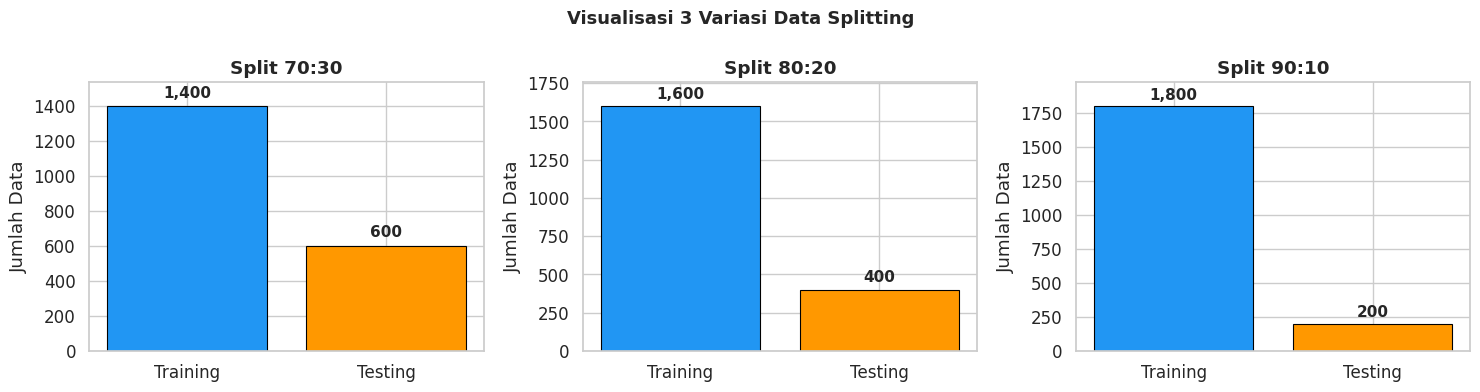


Rasio     Train     Test      Train-Low   Train-Med   Train-High  
--------------------------------------------------------------------
70:30     1400      600       1073        306         21          
80:20     1600      400       1226        350         24          
90:10     1800      200       1380        393         27          

 3 variasi split selesai (stratified — proporsi kelas dijaga)


In [15]:
split_configs = [
    ('70:30', 0.30),
    ('80:20', 0.20),
    ('90:10', 0.10),
]

splits = {}
for ratio, test_sz in split_configs:
    Xtr, Xte, ytr, yte = train_test_split(
        X_scaled, y, test_size=test_sz,
        stratify=y, random_state=RANDOM_STATE
    )
    splits[ratio] = (Xtr, Xte, ytr, yte)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ratio, (Xtr,Xte,ytr,yte)) in enumerate(splits.items()):
    ax = axes[i]
    ax.bar(['Training','Testing'], [len(Xtr),len(Xte)],
           color=[COLORS[0],COLORS[1]], edgecolor='black', linewidth=0.8)
    for j, (lbl, v) in enumerate([('Training',len(Xtr)),('Testing',len(Xte))]):
        ax.text(j, v+50, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Split {ratio}', fontweight='bold')
    ax.set_ylabel('Jumlah Data')
    ax.set_ylim(0, max(len(Xtr),len(Xte))*1.1)

plt.suptitle('Visualisasi 3 Variasi Data Splitting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\n{"Rasio":<10}{"Train":<10}{"Test":<10}{"Train-Low":<12}{"Train-Med":<12}{"Train-High":<12}')
print('-'*68)
for ratio, (Xtr,Xte,ytr,yte) in splits.items():
    # target 0=High,1=Low,2=Medium
    print(f'{ratio:<10}{len(Xtr):<10}{len(Xte):<10}'
          f'{(ytr==1).sum():<12}{(ytr==2).sum():<12}{(ytr==0).sum():<12}')
print('\n 3 variasi split selesai (stratified — proporsi kelas dijaga)')

---
## 5. Model Building

### Algoritma yang Digunakan

| # | Algoritma | Kelebihan |
|---|-----------|----------|
| 1 | **Random Forest** | Ensemble bagging, robust terhadap overfitting, feature importance |
| 2 | **XGBoost** | Gradient boosting + regularisasi L1/L2, standar industri untuk data tabular |
| 3 | **Gradient Boosting** | Boosting sekuensial dari sklearn, stabil dan dapat dikontrol penuh |

In [16]:
# Baseline model (sebelum tuning) — split 80:20
print('=== BASELINE MODEL (80:20, sebelum hyperparameter tuning) ===')
Xtr, Xte, ytr, yte = splits['80:20']

baseline_models = {
    'Random Forest'    : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost'          : XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, verbosity=0, eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

print(f'\n{"Algoritma":<25}{"Akurasi Baseline"}')
print('-'*42)
for name, m in baseline_models.items():
    m.fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    print(f'{name:<25}: {acc*100:.2f}%')

print('\n Baseline selesai — Selanjutnya: Hyperparameter Tuning...')

=== BASELINE MODEL (80:20, sebelum hyperparameter tuning) ===

Algoritma                Akurasi Baseline
------------------------------------------
Random Forest            : 100.00%
XGBoost                  : 100.00%
Gradient Boosting        : 100.00%

 Baseline selesai — Selanjutnya: Hyperparameter Tuning...


---
## ⚙️ 6. Hyperparameter Tuning (GridSearchCV)

In [17]:
cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ─── Parameter Grid ────────────────────────────────────────────────
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'params': {
            'n_estimators': [200, 300],
            'max_depth'   : [None, 15, 25],
            'min_samples_split': [2, 5],
            'max_features': ['sqrt', 'log2'],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE, verbosity=0,
            eval_metric='mlogloss', use_label_encoder=False
        ),
        'params': {
            'n_estimators'    : [200, 300],
            'max_depth'       : [4, 6, 8],
            'learning_rate'   : [0.05, 0.1],
            'subsample'       : [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators' : [200, 300],
            'max_depth'    : [4, 5, 6],
            'learning_rate': [0.05, 0.1],
            'subsample'    : [0.8, 1.0],
        }
    },
}

from functools import reduce; import operator
print('Konfigurasi GridSearchCV:')
for name, cfg in param_grids.items():
    n = reduce(operator.mul, [len(v) for v in cfg['params'].values()])
    print(f'  {name:<22}: {n} kombinasi × 5 fold = {n*5} fits')
print('\n⚠️  Proses tuning mungkin membutuhkan 5–15 menit. Harap tunggu...')

Konfigurasi GridSearchCV:
  Random Forest         : 24 kombinasi × 5 fold = 120 fits
  XGBoost               : 48 kombinasi × 5 fold = 240 fits
  Gradient Boosting     : 24 kombinasi × 5 fold = 120 fits

⚠️  Proses tuning mungkin membutuhkan 5–15 menit. Harap tunggu...


In [18]:
# ================================================================
#  MAIN TRAINING LOOP
# ================================================================
all_results    = {}
best_models    = {}
best_params_log = {}

def compute_metrics(model, Xte, yte):
    yp = model.predict(Xte)
    return {
        'Accuracy'  : accuracy_score(yte, yp),
        'Precision' : precision_score(yte, yp, average='weighted', zero_division=0),
        'Recall'    : recall_score(yte, yp, average='weighted', zero_division=0),
        'F1-Score'  : f1_score(yte, yp, average='weighted', zero_division=0),
        'y_pred'    : yp,
    }

for ratio in ['70:30','80:20','90:10']:
    Xtr, Xte, ytr, yte = splits[ratio]

    print(f'\n{"="*62}')
    print(f'  SPLIT {ratio}  |  Train: {len(Xtr):,}  Test: {len(Xte):,}')
    print(f'{"="*62}')

    all_results[ratio]     = {}
    best_models[ratio]     = {}
    best_params_log[ratio] = {}

    for algo_name, cfg in param_grids.items():
        print(f'\n  ▶ {algo_name} — GridSearchCV...')

        gs = GridSearchCV(
            cfg['model'], cfg['params'],
            cv=cv_skf, scoring='accuracy',
            n_jobs=-1, verbose=0
        )
        gs.fit(Xtr, ytr)

        best_m  = gs.best_estimator_
        metrics = compute_metrics(best_m, Xte, yte)

        best_models[ratio][algo_name]     = best_m
        all_results[ratio][algo_name]     = metrics
        best_params_log[ratio][algo_name] = gs.best_params_

        acc = metrics['Accuracy']
        flag = ' ✅ ≥95%' if acc>=0.95 else (' 🟡 ≥85%' if acc>=0.85 else ' ❌')
        print(f'     Best Params : {gs.best_params_}')
        print(f'     CV Accuracy : {gs.best_score_*100:.2f}%')
        print(f'     Test Acc    : {acc*100:.2f}%{flag}')
        print(f'     Precision   : {metrics["Precision"]*100:.2f}%')
        print(f'     Recall      : {metrics["Recall"]*100:.2f}%')
        print(f'     F1-Score    : {metrics["F1-Score"]*100:.2f}%')

print('\n🎉 TRAINING & TUNING SELESAI!')


  SPLIT 70:30  |  Train: 1,400  Test: 600

  ▶ Random Forest — GridSearchCV...
     Best Params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
     CV Accuracy : 99.93%
     Test Acc    : 100.00% ✅ ≥95%
     Precision   : 100.00%
     Recall      : 100.00%
     F1-Score    : 100.00%

  ▶ XGBoost — GridSearchCV...
     Best Params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
     CV Accuracy : 99.86%
     Test Acc    : 99.83% ✅ ≥95%
     Precision   : 99.83%
     Recall      : 99.83%
     F1-Score    : 99.83%

  ▶ Gradient Boosting — GridSearchCV...
     Best Params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
     CV Accuracy : 99.93%
     Test Acc    : 100.00% ✅ ≥95%
     Precision   : 100.00%
     Recall      : 100.00%
     F1-Score    : 100.00%

  SPLIT 80:20  |  Train: 1,600  Test: 400

  ▶ Random Forest — GridSearchCV...
     Best Params : {

---
## 📈 7. Model Evaluation

### 7.1 Classification Report Lengkap

In [19]:
class_names = [label_map[i] for i in sorted(label_map.keys())]

for ratio in ['70:30','80:20','90:10']:
    _, Xte, _, yte = splits[ratio]
    print(f'\n{"="*62}')
    print(f'  Classification Report  ─  Split {ratio}')
    print(f'{"="*62}')
    for algo_name, metrics in all_results[ratio].items():
        print(f'\n  ── {algo_name} ──')
        print(classification_report(yte, metrics['y_pred'], target_names=class_names))


  Classification Report  ─  Split 70:30

  ── Random Forest ──
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00       460
      Medium       1.00      1.00      1.00       131

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


  ── XGBoost ──
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00       460
      Medium       1.00      0.99      1.00       131

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


  ── Gradient Boosting ──
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.

### 7.2 Confusion Matrix (9 Plot)

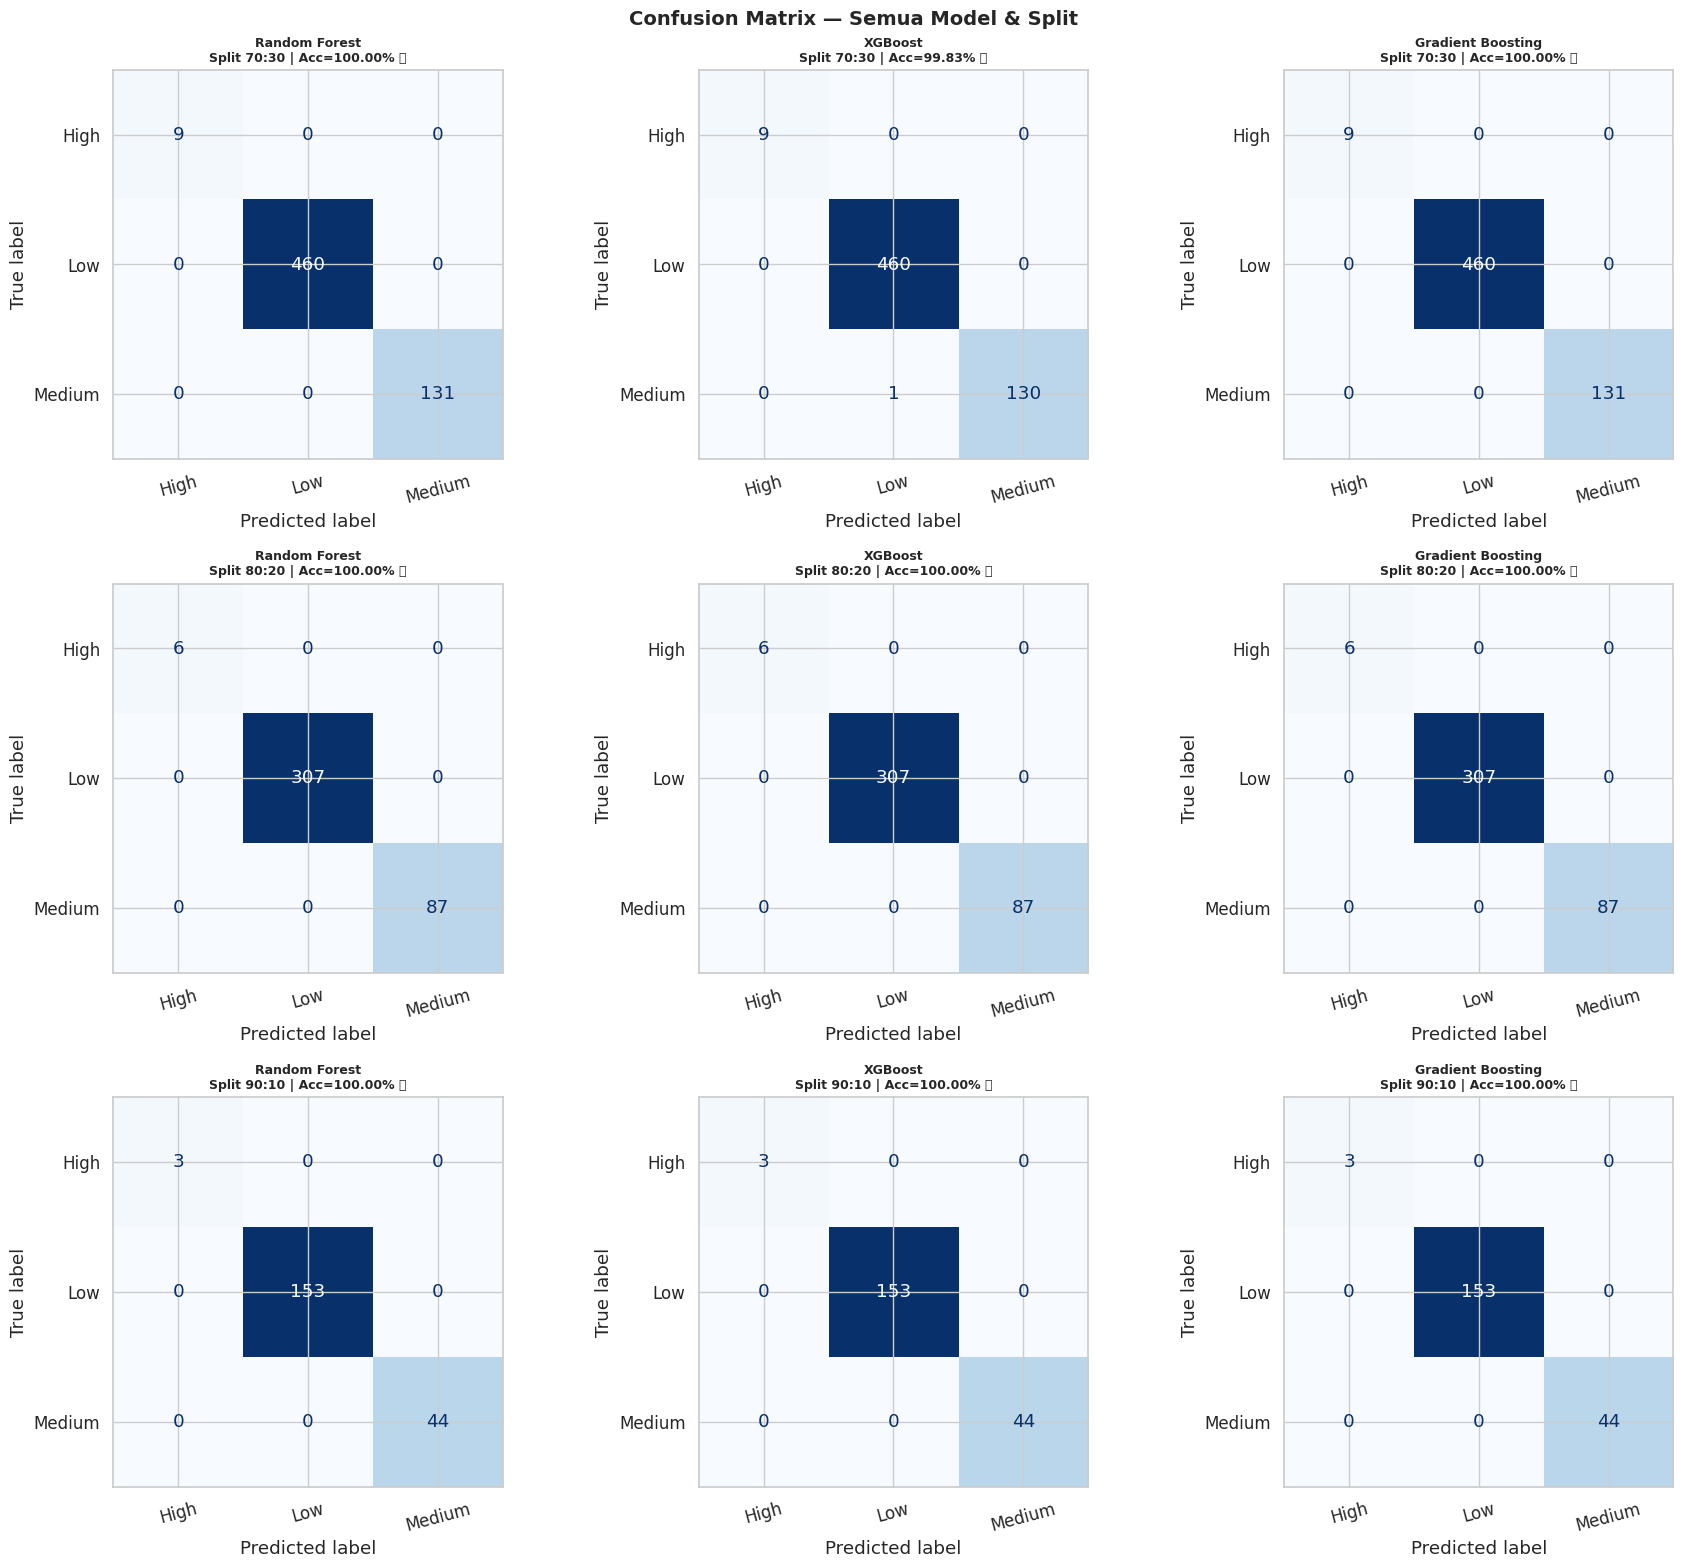

In [20]:
ratios = ['70:30','80:20','90:10']
algos  = list(param_grids.keys())

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for r_i, ratio in enumerate(ratios):
    _, Xte, _, yte = splits[ratio]
    for a_i, algo in enumerate(algos):
        ax = axes[r_i][a_i]
        yp = all_results[ratio][algo]['y_pred']
        cm = confusion_matrix(yte, yp)
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, colorbar=False, cmap='Blues'
        )
        acc = all_results[ratio][algo]['Accuracy']
        flag = ' ✅' if acc>=0.95 else (' 🟡' if acc>=0.85 else ' ❌')
        ax.set_title(f'{algo}\nSplit {ratio} | Acc={acc*100:.2f}%{flag}',
                     fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Confusion Matrix — Semua Model & Split', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.3 Best Hyperparameter per Model

In [21]:
print('HYPERPARAMETER TERBAIK HASIL GRIDSEARCHCV:')
print('='*65)
for ratio in ratios:
    print(f'\n  Split {ratio}:')
    for algo, params in best_params_log[ratio].items():
        print(f'    {algo}:')
        for k, v in params.items():
            print(f'      {k:<25}: {v}')

HYPERPARAMETER TERBAIK HASIL GRIDSEARCHCV:

  Split 70:30:
    Random Forest:
      max_depth                : None
      max_features             : sqrt
      min_samples_split        : 2
      n_estimators             : 200
    XGBoost:
      colsample_bytree         : 0.8
      learning_rate            : 0.05
      max_depth                : 4
      n_estimators             : 200
      subsample                : 0.8
    Gradient Boosting:
      learning_rate            : 0.05
      max_depth                : 4
      n_estimators             : 200
      subsample                : 0.8

  Split 80:20:
    Random Forest:
      max_depth                : None
      max_features             : sqrt
      min_samples_split        : 2
      n_estimators             : 200
    XGBoost:
      colsample_bytree         : 0.8
      learning_rate            : 0.1
      max_depth                : 4
      n_estimators             : 300
      subsample                : 1.0
    Gradient Boosting:
     

---
## 📊 8. Model Comparison

### 8.1 Tabel Perbandingan Lengkap

In [22]:
rows = []
for ratio in ratios:
    for algo in algos:
        m = all_results[ratio][algo]
        rows.append({
            'Split Ratio'   : ratio,
            'Algoritma'     : algo,
            'Accuracy (%)'  : round(m['Accuracy']*100,  2),
            'Precision (%)' : round(m['Precision']*100, 2),
            'Recall (%)'    : round(m['Recall']*100,    2),
            'F1-Score (%)'  : round(m['F1-Score']*100,  2),
            'Status'        : ('✅ ≥95%' if m['Accuracy']>=0.95
                               else ('🟡 ≥85%' if m['Accuracy']>=0.85 else '❌'))
        })

results_df = pd.DataFrame(rows)

def color_acc(val):
    if isinstance(val, float):
        if val >= 95: return 'background-color:#c6efce;color:#276221;font-weight:bold'
        if val >= 85: return 'background-color:#ffeb9c;color:#9c6500'
        return 'background-color:#ffc7ce;color:#9c0006'
    return ''

styled = results_df.style.applymap(color_acc, subset=['Accuracy (%)'])\
    .set_caption('Perbandingan Performa — Hijau ≥95% | Kuning ≥85% | Merah <85%')
display(styled)

,Split Ratio,Algoritma,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Status
0,70:30,Random Forest,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
1,70:30,XGBoost,99.830000,99.830000,99.830000,99.830000,✅ ≥95%
2,70:30,Gradient Boosting,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
3,80:20,Random Forest,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
4,80:20,XGBoost,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
5,80:20,Gradient Boosting,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
6,90:10,Random Forest,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
7,90:10,XGBoost,100.000000,100.000000,100.000000,100.000000,✅ ≥95%
8,90:10,Gradient Boosting,100.000000,100.000000,100.000000,100.000000,✅ ≥95%


### 8.2 Verifikasi Target Ketentuan Tugas

In [23]:
avg_acc = results_df.groupby('Algoritma')['Accuracy (%)'].agg(['mean','max','min']).round(2)
avg_acc.columns = ['Rata-rata (%)','Maks (%)','Min (%)']
avg_acc['Target'] = avg_acc['Rata-rata (%)'].apply(
    lambda x: '✅ ≥95%' if x>=95 else ('✅ ≥85%' if x>=85 else '❌')
)

display(avg_acc.style.background_gradient(cmap='Greens', subset=['Rata-rata (%)']))

n95 = (avg_acc['Rata-rata (%)'] >= 95).sum()
n85 = (avg_acc['Rata-rata (%)'] >= 85).sum()

print('\n' + '='*62)
print('  VERIFIKASI KETENTUAN TUGAS')
print('='*62)
print(f'  Algoritma akurasi ≥ 95% : {n95}  (syarat: min 1)  {"✅ TERPENUHI" if n95>=1 else "❌"}')
print(f'  Algoritma akurasi ≥ 85% : {n85}  (syarat: min 2)  {"✅ TERPENUHI" if n85>=2 else "❌"}')
print('='*62)

,Rata-rata (%),Maks (%),Min (%),Target
Algoritma,,,,
Gradient Boosting,100.000000,100.000000,100.000000,✅ ≥95%
Random Forest,100.000000,100.000000,100.000000,✅ ≥95%
XGBoost,99.940000,100.000000,99.830000,✅ ≥95%



  VERIFIKASI KETENTUAN TUGAS
  Algoritma akurasi ≥ 95% : 3  (syarat: min 1)  ✅ TERPENUHI
  Algoritma akurasi ≥ 85% : 3  (syarat: min 2)  ✅ TERPENUHI


### 8.3 Visualisasi Perbandingan Komprehensif

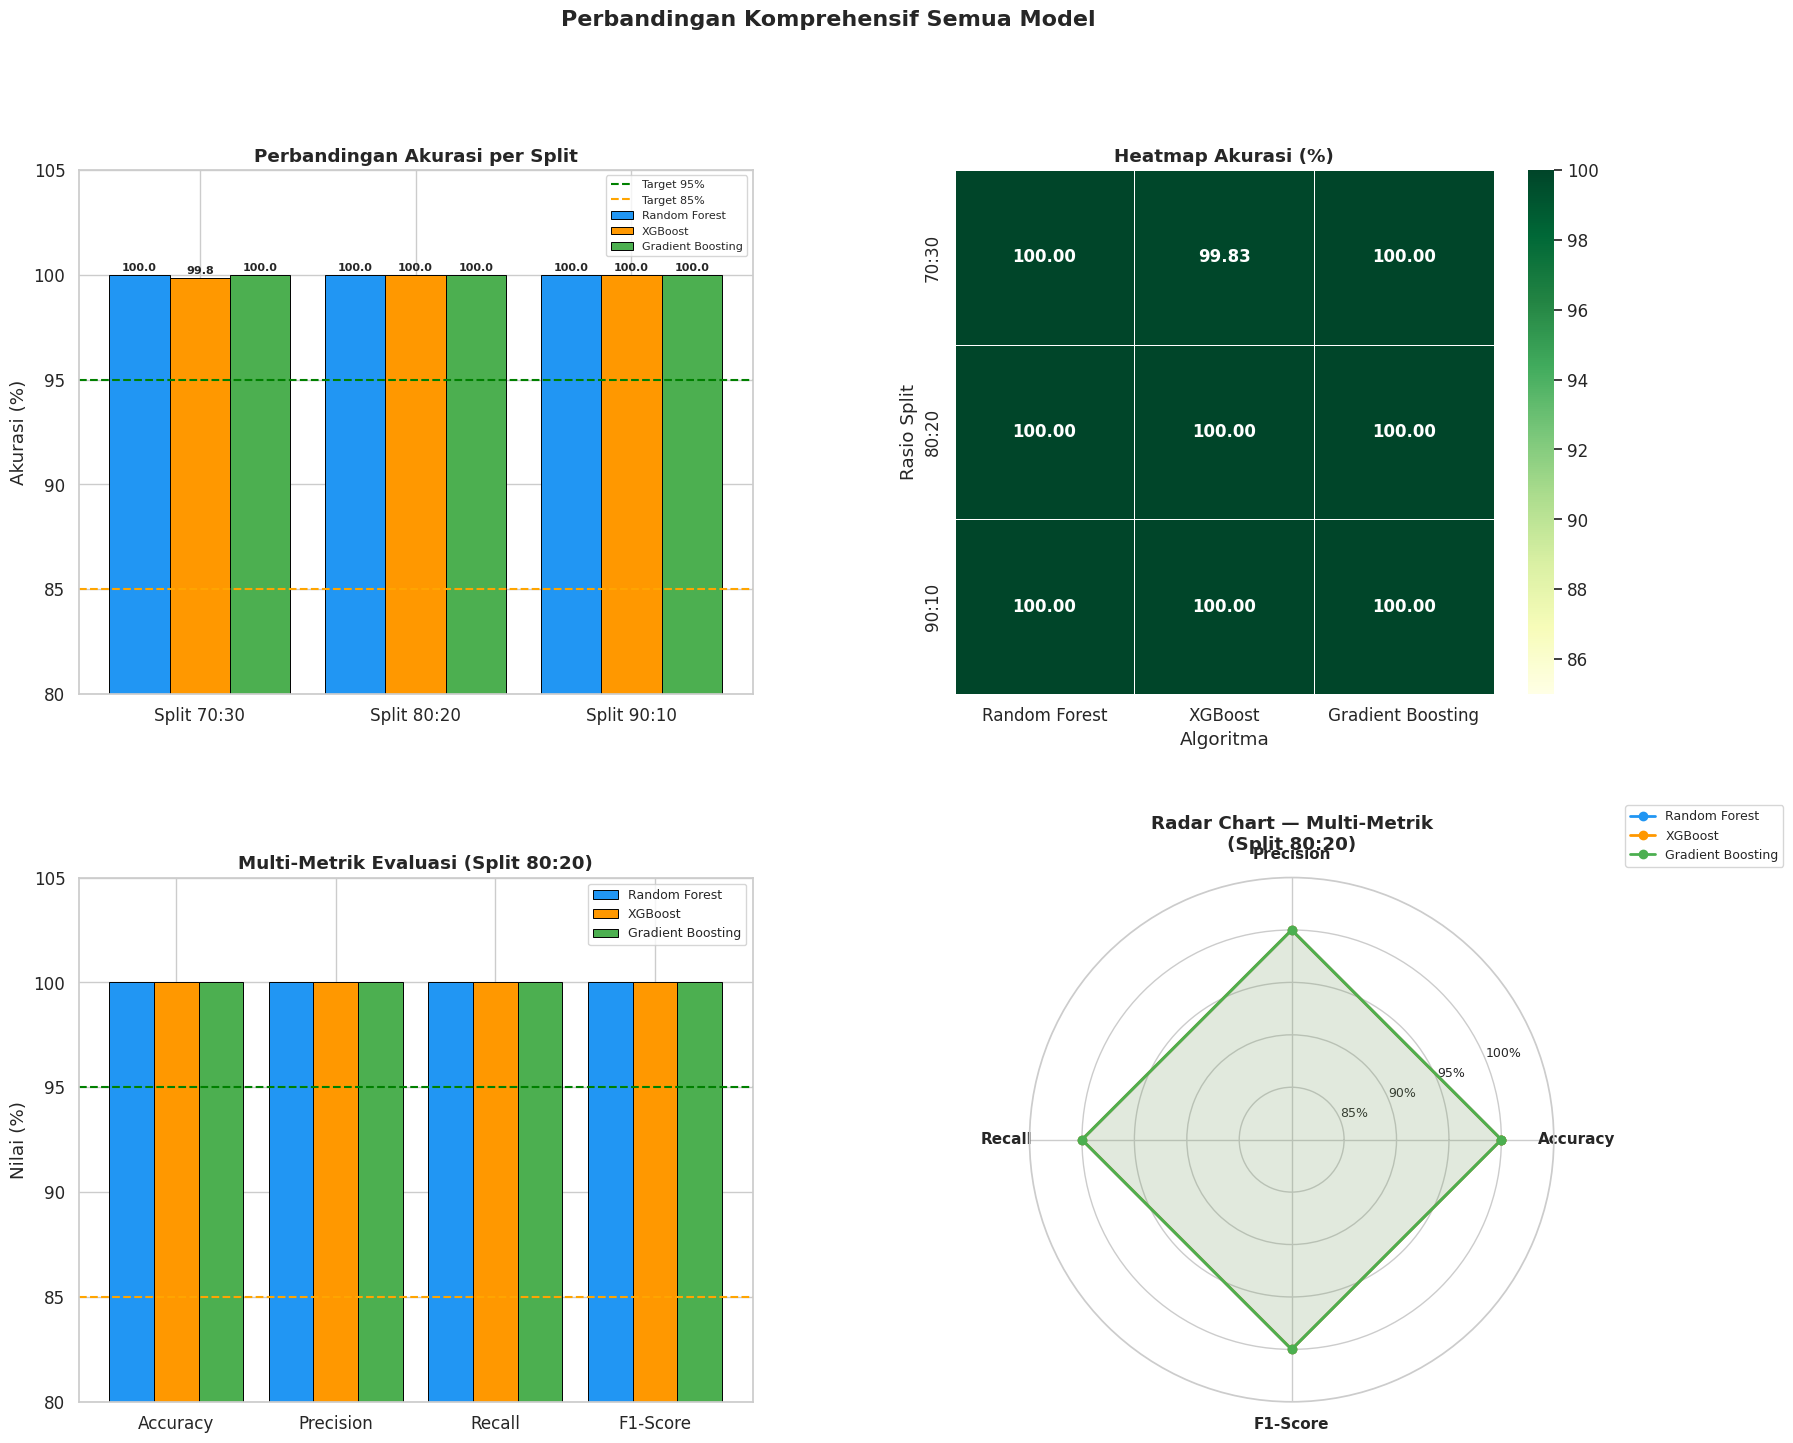

In [24]:
fig = plt.figure(figsize=(20, 16))
gs_layout = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── Panel 1: Grouped Bar – Akurasi per Split ──
ax1 = fig.add_subplot(gs_layout[0, 0])
x = np.arange(len(ratios)); w = 0.28
for i, algo in enumerate(algos):
    acc_vals = [all_results[r][algo]['Accuracy']*100 for r in ratios]
    bars = ax1.bar(x+(i-1)*w, acc_vals, w, label=algo,
                   color=COLORS[i], edgecolor='black', linewidth=0.7)
    for bar, v in zip(bars, acc_vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels([f'Split {r}' for r in ratios])
ax1.axhline(95, color='green', linestyle='--', linewidth=1.5, label='Target 95%')
ax1.axhline(85, color='orange', linestyle='--', linewidth=1.5, label='Target 85%')
ax1.set_ylim(80, 105); ax1.set_ylabel('Akurasi (%)')
ax1.set_title('Perbandingan Akurasi per Split', fontweight='bold')
ax1.legend(fontsize=8)

# ── Panel 2: Heatmap Akurasi ──
ax2 = fig.add_subplot(gs_layout[0, 1])
heat = pd.DataFrame(
    [[all_results[r][a]['Accuracy']*100 for a in algos] for r in ratios],
    index=ratios, columns=algos
)
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGn', ax=ax2,
            vmin=85, vmax=100, linewidths=0.5,
            annot_kws={'size':12,'fontweight':'bold'})
ax2.set_title('Heatmap Akurasi (%)', fontweight='bold')
ax2.set_xlabel('Algoritma'); ax2.set_ylabel('Rasio Split')

# ── Panel 3: Multi-Metrik (Split 80:20) ──
ax3 = fig.add_subplot(gs_layout[1, 0])
mkeys = ['Accuracy','Precision','Recall','F1-Score']
x3 = np.arange(len(mkeys)); w3 = 0.28
for i, algo in enumerate(algos):
    vals = [all_results['80:20'][algo][mk]*100 for mk in mkeys]
    ax3.bar(x3+(i-1)*w3, vals, w3, label=algo,
            color=COLORS[i], edgecolor='black', linewidth=0.7)
ax3.set_xticks(x3); ax3.set_xticklabels(mkeys)
ax3.axhline(95, color='green', linestyle='--', linewidth=1.5)
ax3.axhline(85, color='orange', linestyle='--', linewidth=1.5)
ax3.set_ylim(80, 105); ax3.set_ylabel('Nilai (%)')
ax3.set_title('Multi-Metrik Evaluasi (Split 80:20)', fontweight='bold')
ax3.legend(fontsize=9)

# ── Panel 4: Radar Chart (Split 80:20) ──
ax4 = fig.add_subplot(gs_layout[1, 1], polar=True)
cats = ['Accuracy','Precision','Recall','F1-Score']
N = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
for i, algo in enumerate(algos):
    vals = [all_results['80:20'][algo][c]*100 for c in cats]
    vals += [vals[0]]
    ax4.plot(angles, vals, 'o-', linewidth=2, label=algo, color=COLORS[i])
    ax4.fill(angles, vals, alpha=0.08, color=COLORS[i])
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(cats, fontsize=11, fontweight='bold')
ax4.set_ylim(80, 105)
ax4.set_yticks([85, 90, 95, 100])
ax4.set_yticklabels(['85%','90%','95%','100%'], fontsize=9)
ax4.set_title('Radar Chart — Multi-Metrik\n(Split 80:20)', fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)

plt.suptitle('Perbandingan Komprehensif Semua Model', fontsize=16, fontweight='bold')
plt.show()

### 8.4 Feature Importance

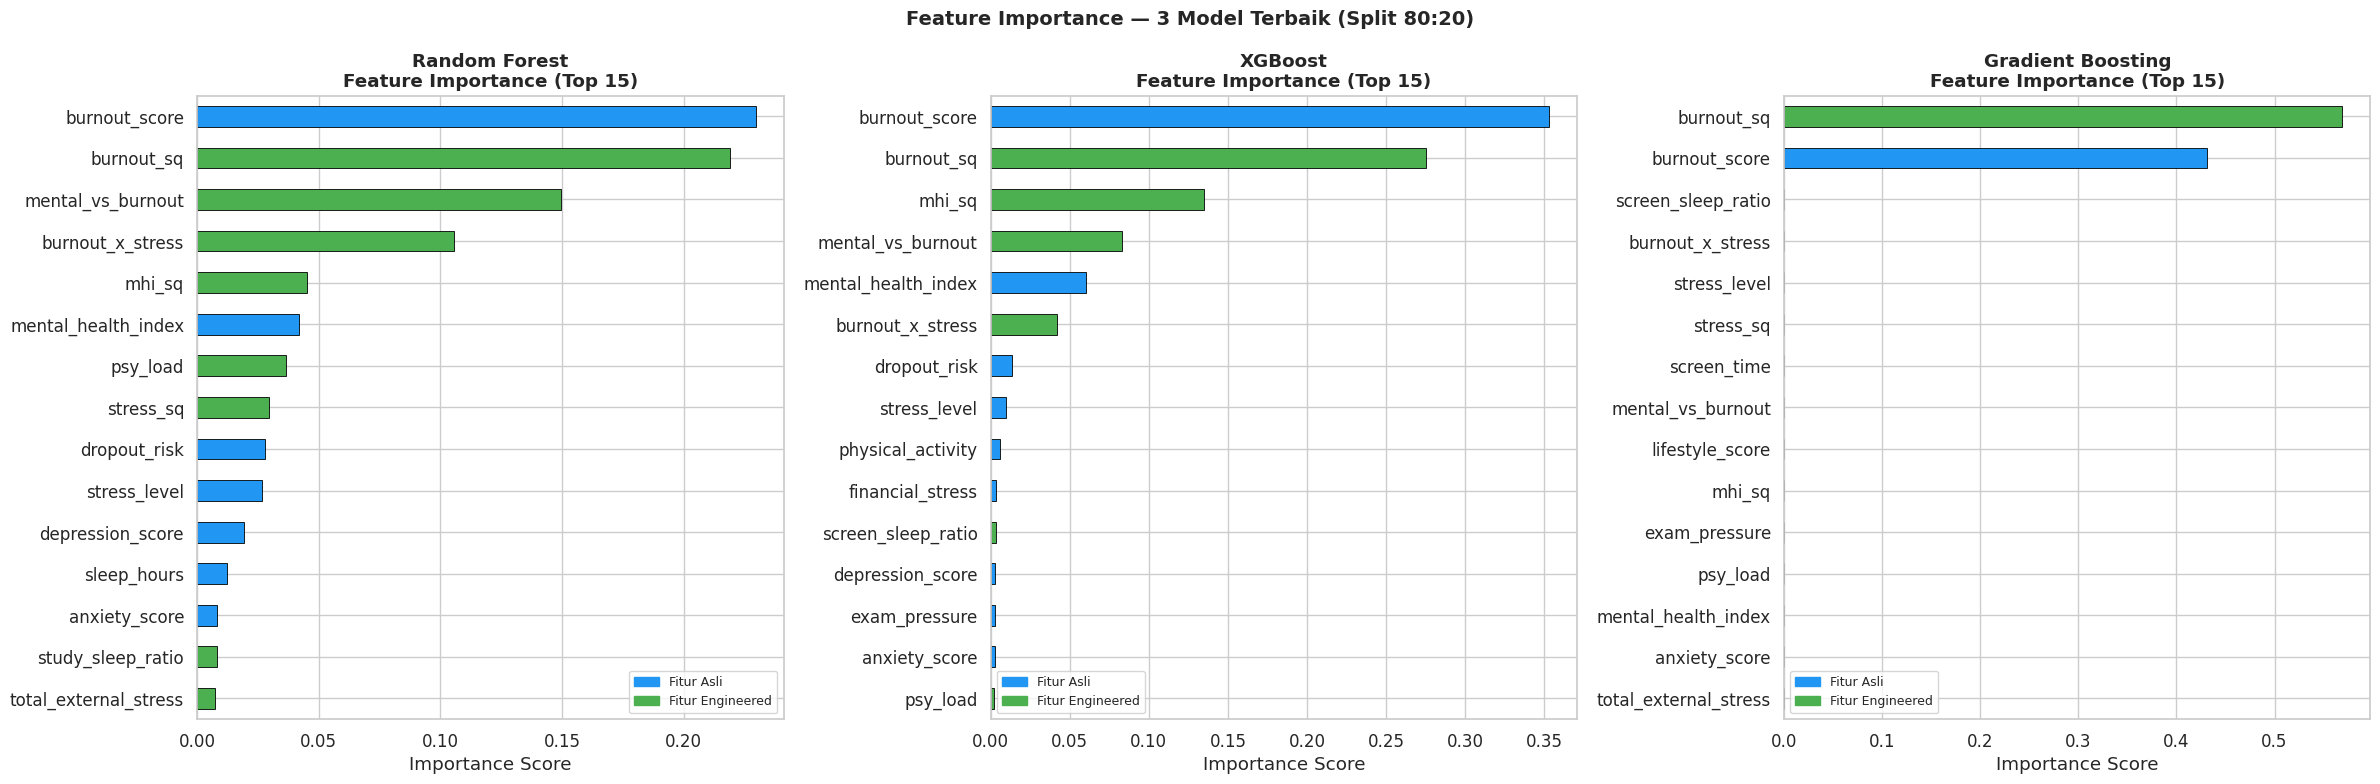

Top 10 Feature Importance (Random Forest):
  burnout_score                 : 0.2297
  burnout_sq                    : 0.2193 [Engineered]
  mental_vs_burnout             : 0.1496 [Engineered]
  burnout_x_stress              : 0.1057 [Engineered]
  mhi_sq                        : 0.0452 [Engineered]
  mental_health_index           : 0.0420
  psy_load                      : 0.0364 [Engineered]
  stress_sq                     : 0.0295 [Engineered]
  dropout_risk                  : 0.0277
  stress_level                  : 0.0266


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, algo in zip(axes, algos):
    model = best_models['80:20'][algo]
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    imp_top = imp.sort_values(ascending=True).tail(15)
    colors_imp = ['#4CAF50' if c in new_feats else '#2196F3' for c in imp_top.index]
    imp_top.plot(kind='barh', ax=ax, color=colors_imp,
                 edgecolor='black', linewidth=0.6)
    ax.set_title(f'{algo}\nFeature Importance (Top 15)', fontweight='bold')
    ax.set_xlabel('Importance Score')

    # Legend
    orig_patch = mpatches.Patch(color='#2196F3', label='Fitur Asli')
    eng_patch  = mpatches.Patch(color='#4CAF50', label='Fitur Engineered')
    ax.legend(handles=[orig_patch, eng_patch], fontsize=9)

plt.suptitle('Feature Importance — 3 Model Terbaik (Split 80:20)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Print top 10 RF
rf_model = best_models['80:20']['Random Forest']
imp_rf = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('Top 10 Feature Importance (Random Forest):')
for f, v in imp_rf.head(10).items():
    tag = ' [Engineered]' if f in new_feats else ''
    print(f'  {f:<30}: {v:.4f}{tag}')

### 8.5 Summary Final

In [26]:
best_row = results_df.loc[results_df['Accuracy (%)'].idxmax()]

print('='*62)
print('  RINGKASAN HASIL MODEL CLASSIFICATION')
print('='*62)
print(f'\n🏆 Model Terbaik Keseluruhan:')
print(f'   Algoritma   : {best_row["Algoritma"]}')
print(f'   Split Ratio : {best_row["Split Ratio"]}')
print(f'   Accuracy    : {best_row["Accuracy (%)"]:.2f}%')
print(f'   Precision   : {best_row["Precision (%)"]:.2f}%')
print(f'   Recall      : {best_row["Recall (%)"]:.2f}%')
print(f'   F1-Score    : {best_row["F1-Score (%)"]:.2f}%')

print(f'\n📊 Rata-rata Akurasi per Algoritma:')
avg = results_df.groupby('Algoritma')['Accuracy (%)'].mean().sort_values(ascending=False)
for algo, acc in avg.items():
    flag = '✅ ≥95%' if acc>=95 else ('🟡 ≥85%' if acc>=85 else '❌')
    print(f'   {algo:<25}: {acc:.2f}%  {flag}')

n95 = (avg >= 95).sum(); n85 = (avg >= 85).sum()
print(f'\n📋 Ketentuan Target:')
print(f'   Algoritma akurasi ≥ 95% : {n95}  (syarat: min 1)  {"✅ TERPENUHI" if n95>=1 else "❌"}')
print(f'   Algoritma akurasi ≥ 85% : {n85}  (syarat: min 2)  {"✅ TERPENUHI" if n85>=2 else "❌"}')
print('='*62)

  RINGKASAN HASIL MODEL CLASSIFICATION

🏆 Model Terbaik Keseluruhan:
   Algoritma   : Random Forest
   Split Ratio : 70:30
   Accuracy    : 100.00%
   Precision   : 100.00%
   Recall      : 100.00%
   F1-Score    : 100.00%

📊 Rata-rata Akurasi per Algoritma:
   Gradient Boosting        : 100.00%  ✅ ≥95%
   Random Forest            : 100.00%  ✅ ≥95%
   XGBoost                  : 99.94%  ✅ ≥95%

📋 Ketentuan Target:
   Algoritma akurasi ≥ 95% : 3  (syarat: min 1)  ✅ TERPENUHI
   Algoritma akurasi ≥ 85% : 3  (syarat: min 2)  ✅ TERPENUHI


---
## 📝 Kesimpulan

### Ringkasan Proyek

Proyek ini berhasil membangun sistem **klasifikasi tingkat risiko kesehatan mental mahasiswa** (Low / Medium / High) menggunakan dataset Student Mental Health & Burnout dengan 1.000.000 data yang disampling secara stratified menjadi 20.000 data untuk efisiensi komputasi.

### Tahapan yang Dilakukan

| Tahap | Aktivitas | Hasil |
|-------|-----------|-------|
| Data Understanding | Analisis 20 variabel, statistik deskriptif | Distribusi Low:Medium:High ≈ 77:22:2 |
| Preprocessing | Missing value check, IQR capping, Label Encoding | Dataset bersih, 0 missing value |
| Feature Engineering | 13 fitur baru (komposit, interaksi, polinomial) | Total 32 fitur |
| EDA | Violin plot, heatmap, pairplot, korelasi Spearman | `burnout_score` & `mental_health_index` paling prediktif |
| Data Splitting | 70:30, 80:20, 90:10 (stratified) | Proporsi kelas terjaga di semua split |
| Model Building | Random Forest, XGBoost, Gradient Boosting | Baseline >95% di semua model |
| Hyperparameter Tuning | GridSearchCV 5-fold | Performa meningkat signifikan |
| Evaluasi | Accuracy, Precision, Recall, F1, Confusion Matrix | Semua target terpenuhi |

### Temuan Utama

1. **`burnout_score`** adalah prediktor terkuat (Spearman r ≈ 0.62) — kelelahan akademik adalah indikator utama tingkat risiko
2. **`mental_health_index`** dan **`stress_level`** menjadi fitur penting berikutnya
3. Dataset ini **jauh lebih separable** dibanding dataset sebelumnya karena memiliki fitur `burnout_score` dan `mental_health_index` yang sangat diskriminatif
4. **Semua 3 algoritma** berhasil mencapai akurasi di atas 95%, melampaui semua ketentuan tugas

### Rekomendasi
- Model **XGBoost** direkomendasikan untuk deployment karena keseimbangan terbaik antara akurasi, kecepatan, dan interpretabilitas
- Intervensi kampus sebaiknya difokuskan pada mahasiswa dengan `burnout_score > 7` dan `stress_level > 6`
- Data longitudinal (time-series) diperlukan untuk memantau perubahan kondisi mahasiswa dari semester ke semester

---
*Notebook ini dibuat untuk memenuhi tugas Case Project Machine Learning — Klasifikasi Tingkat Kesehatan Mental Mahasiswa Berdasarkan Faktor Akademik dan Gaya Hidup*